# 00A — Prepare Compact ERA5 Teaching Datasets
## การเตรียมชุดข้อมูล ERA5 ขนาดย่อมสำหรับการเรียนการสอน Reanalysis, Weather Maps และ Spatiotemporal Analysis

**สถานะของ Notebook:** Instructor / Dataset Engineering Notebook  
**กลุ่มผู้ใช้หลัก:** ผู้สอน หรือผู้ช่วยสอน  
**กลุ่มผู้เรียนปลายทาง:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลต้นทาง:** ERA5 NetCDF จำนวน 3 ไฟล์

Notebook นี้มีหน้าที่เตรียม **compact canonical teaching datasets** จากไฟล์ ERA5 ขนาดใหญ่ ก่อนนำไฟล์ที่เตรียมแล้วไปอัปโหลดบน GitHub เพื่อให้นิสิตดาวน์โหลดมาใช้ใน Notebook 00–09 ของรายวิชา

แนวคิดหลักคือ:

```text
Original ERA5 files
        ↓
Data audit
        ↓
Spatial subset
        ↓
Temporal / level / variable selection
        ↓
Optional spatial coarsening
        ↓
Compression
        ↓
Metadata + checksum
        ↓
Compact teaching NetCDF
        ↓
Upload to GitHub
        ↓
Student notebooks
```

> จุดประสงค์ของ Notebook นี้ไม่ใช่การวิเคราะห์อุตุนิยมวิทยาโดยตรง แต่เป็นการสร้าง **ข้อมูลกลางสำหรับการเรียน** ที่มีขนาดเหมาะสม มีที่มาชัดเจน และตรวจสอบย้อนกลับได้

# เหตุผลที่ควรเตรียมข้อมูลก่อนสอน

ไฟล์ ERA5 ต้นฉบับมีขนาดหลายร้อย MB ต่อไฟล์ และบางไฟล์ครอบคลุมทั้งโลก ซึ่งไม่จำเป็นสำหรับทุกบทเรียน

หากให้นิสิตดาวน์โหลดไฟล์ global เต็มชุด จะเกิดปัญหา:

- download ช้า
- ใช้พื้นที่ Google Drive มาก
- ใช้ RAM มากเกินจำเป็น
- เปิดข้อมูลช้าใน Colab
- ทำให้ผู้เรียนสนใจ technical burden มากกว่าหลักการทางภูมิศาสตร์และอุตุนิยมวิทยา

แนวทางที่เหมาะกว่าคือ:

```text
เก็บเฉพาะข้อมูลที่จำเป็น
+
คงข้อมูลทางกายภาพที่ต้องใช้
+
รักษา metadata
+
บันทึกวิธี preprocessing อย่างโปร่งใส
```

จึงได้ชุดข้อมูลที่เหมาะกับการเรียนและ reproducible

# Learning outcomes ของ Notebook 00A

เมื่อศึกษาบทนี้ ผู้สอนหรือนิสิตระดับสูงควรสามารถ:

1. อธิบายว่า ERA5 เป็น **reanalysis** ไม่ใช่ observation โดยตรง
2. อธิบายโครงสร้างข้อมูลหลายมิติแบบ `time × level × latitude × longitude`
3. ตรวจสอบ dimensions, coordinates, variables, units และ attributes ของ NetCDF
4. แยกความหมายของ **subsetting**, **subsampling**, **coarsening** และ **regridding**
5. เลือก spatial domain ให้เหมาะกับคำถามการเรียน
6. เลือก pressure levels และ variables ที่จำเป็น
7. ลด spatial resolution อย่างถูกหลักด้วย spatial averaging
8. อธิบายผลของการแปลง `float64 → float32`
9. ใช้ NetCDF compression เพื่อลดขนาดไฟล์
10. ตรวจสอบ output หลังเขียนไฟล์
11. สร้าง SHA256 checksum
12. สร้าง data manifest
13. ประเมินว่าไฟล์พร้อมอัปโหลด GitHub หรือไม่
14. รักษา provenance ของข้อมูลตลอด workflow

# 1. ERA5 คืออะไร?

ERA5 เป็น **atmospheric reanalysis** ซึ่งสร้างจากการรวม:

```text
Observations
    +
Numerical weather prediction model
    +
Data assimilation
    ↓
Spatially and temporally complete estimate
of the atmospheric state
```

ดังนั้น ERA5 ไม่ควรถูกเรียกว่า “ข้อมูลตรวจวัดโดยตรง”

แนวคิดสำคัญ:

```text
Observation ≠ Reanalysis ≠ Model forecast
```

- **Observation** คือสิ่งที่เครื่องมือวัด
- **Forecast** คือการคาดการณ์จาก initial state ไปยังอนาคต
- **Reanalysis** คือการประมวลสภาพบรรยากาศย้อนหลังอย่างสม่ำเสมอด้วย model + observations

สำหรับการเรียนภูมิศาสตร์และสิ่งแวดล้อม ERA5 เหมาะมากเพราะทำให้เราเห็นบรรยากาศเป็นข้อมูลเชิงพื้นที่และเวลาแบบต่อเนื่อง

# 2. Atmospheric data cube

ข้อมูล reanalysis สามารถคิดเป็น **4-D atmospheric data cube**

```text
                 longitude
                    →
          ┌─────────────────┐
 level ↑  │                 │
          │   atmosphere    │
          │                 │
          └─────────────────┘
              latitude
                  +
                 time
```

ตัวแปรหนึ่ง เช่น temperature อาจมีโครงสร้าง:

```text
temperature(time, level, latitude, longitude)
```

หรือเขียนเชิงคณิตศาสตร์เป็น:

$$
T = T(t,p,\phi,\lambda)
$$

โดย:

- $t$ = เวลา
- $p$ = pressure level
- $\phi$ = latitude
- $\lambda$ = longitude

นี่คือพื้นฐานของการวิเคราะห์ **spatiotemporal atmospheric data**

# 3. Spatial resolution กับ grid spacing

ERA5 pressure-level data โดยทั่วไปใช้ regular latitude–longitude grid

หาก grid spacing เท่ากับ $0.25^\circ$:

```text
longitude: every 0.25°
latitude : every 0.25°
```

แต่ควรจำว่า:

> **grid spacing ไม่เท่ากับ effective physical resolution ของ atmosphere**

การลดจาก $0.25^\circ$ เป็น $0.5^\circ$ ใน Notebook นี้ทำเพื่อให้เหมาะกับการเรียนและลดขนาดไฟล์ ไม่ได้หมายความว่า original data “วัด” ที่ resolution ใหม่

# 4. Subsetting, subsampling, coarsening และ regridding ต่างกันอย่างไร?

### Spatial subsetting

เลือกเฉพาะพื้นที่จาก grid เดิม:

```text
Global ERA5
    ↓
60–130°E, 5°S–45°N
```

ค่าข้อมูลและ grid spacing เดิมไม่เปลี่ยน

### Subsampling

เลือกบาง grid points เช่นทุกจุดที่ 2

```text
0.25° → เลือกทุก 2 grid cells → 0.5°
```

วิธีนี้ไม่ได้เฉลี่ยข้อมูล และอาจสูญเสีย spatial information

### Coarsening

รวมหลาย grid cells แล้วหาค่าเฉลี่ย

สำหรับ 2 × 2 cells:

$$
\bar{X}_{i,j}
=
\frac{1}{4}
\sum_{m=1}^{2}
\sum_{n=1}^{2}
X_{m,n}
$$

นี่เป็นวิธีหลักที่ใช้ใน Notebook นี้สำหรับลด $0.25^\circ$ → $0.5^\circ$

### Regridding

สร้างค่าบน grid ใหม่ โดยอาจใช้:

- nearest neighbor
- bilinear interpolation
- conservative remapping

Notebook 00A นี้ **ไม่ทำ general regridding** เพราะไม่จำเป็นสำหรับ teaching datasets ที่ออกแบบไว้

# 5. Source datasets และ teaching outputs ที่ต้องการ

Notebook นี้สมมติว่ามีไฟล์ต้นทาง 3 ไฟล์ใน Google Drive:

```text
era5_daily_2_5oct_2011_globe.nc
era5_hourly4_sep_oct_2011_globe.nc
era5_monthly_mean_globe.nc
```

โดย v2 จะสร้าง teaching datasets 3 กลุ่มที่ออกแบบให้ **ต่ำกว่า 25 MB ต่อไฟล์** เมื่อเป็นไปได้ เพื่อรองรับ GitHub web upload

### A. EVENT dataset

สำหรับ Noul / early October 2011 synoptic analysis

```text
Domain:
60–130°E
5°S–45°N

Source grid:
0.25°

Teaching grid:
0.5° by 2×2 spatial averaging

Time:
four daily 00-UTC synoptic snapshots

Pressure levels:
คงทุก level ที่มีใน source

Variables:
คงตัวแปรอุตุนิยมวิทยาหลักที่ source มี
```

### B. SPATIOTEMPORAL dataset

สำหรับ Hovmöller และ propagation

```text
Period:
September–October 2011

Domain:
40–160°E
5–30°N

Primary variable:
850-hPa zonal wind

Temporal spacing:
ตรวจจาก source จริง — คาดประมาณ 6-hourly

Teaching grid:
0.5°
```

### C. MONTHLY BASELINE dataset

สำหรับสร้าง climatological mean และ anomaly ใน Student Notebook 07–08

```text
Source content:
January and July monthly means for individual years

Domain:
60–140°E
10°S–45°N

Pressure:
850 hPa

Teaching grid:
0.5°
```

> MONTHLY BASELINE ยังไม่ใช่ climatology ที่คำนวณเสร็จแล้ว  
> climatology จะเกิดเมื่อ Student Notebook นำ monthly means หลายปีมาเฉลี่ยตามเดือน

Notebook จะ audit source ก่อนเสมอ และจะไม่สมมติว่าข้อมูลมี month/level/variable ครบโดยไม่ตรวจสอบ

# 6. หลักการสำคัญ: Preserve source meaning

Notebook 00A จะพยายาม **ไม่เปลี่ยนความหมายทางกายภาพของตัวแปร**

สิ่งที่ทำ:

- spatial subset
- temporal subset เมื่อจำเป็น
- pressure-level selection เมื่อจำเป็น
- spatial averaging สำหรับ teaching grid
- `float32` storage
- NetCDF compression
- metadata augmentation

สิ่งที่ยังไม่ทำ:

- ไม่แปลง Kelvin → °C
- ไม่แปลง geopotential → geopotential height
- ไม่คำนวณ wind speed
- ไม่คำนวณ vorticity ใหม่
- ไม่คำนวณ anomaly
- ไม่ทำ smoothing ทางอุตุนิยมวิทยา

เหตุผลคือ:

> **Data-preparation stage ควรแยกจาก scientific-analysis stage**

เพื่อให้นิสิตเห็นชัดว่าตัวแปรที่เรียนใน Notebook 01–09 มาจาก source data หรือมาจากการคำนวณในบทเรียนใด

# 7. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install libraries

import sys
import subprocess

PACKAGE_SPECS = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "tabulate>=0.9",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("Installing/checking packages ...")
subprocess.check_call(cmd)
print("Package installation complete.")

Installing/checking packages ...
Package installation complete.


# 8. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "google.colab not found — using current directory:"
    )
    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 9. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import hashlib
import json
import math
import os
import sys
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

SOFTWARE_VERSIONS = pd.DataFrame(
    {
        "software": [
            "Python",
            "NumPy",
            "pandas",
            "xarray",
            "Matplotlib",
        ],
        "version": [
            sys.version.split()[0],
            np.__version__,
            pd.__version__,
            xr.__version__,
            matplotlib.__version__,
        ],
    }
)

display(
    SOFTWARE_VERSIONS
)

,software,version
0,Python,3.13.15
1,NumPy,2.1.3
2,pandas,2.2.3
3,xarray,2025.12.0
4,Matplotlib,3.10.0


# 10. กำหนด path ของไฟล์ต้นทาง

จากโครงสร้าง Google Drive เดิม ตัวอย่าง path คือ:

```text
MyDrive/
└── 1ข้อมูลยูทูปmetpy/
    └── 2data/
        ├── era5_daily_2_5oct_2011_globe.nc
        ├── era5_hourly4_sep_oct_2011_globe.nc
        └── era5_monthly_mean_globe.nc
```

หาก folder ของผู้สอนต่างจากนี้ ให้แก้เฉพาะ `SOURCE_DIR`

In [4]:
# CELL 4 — Source paths

SOURCE_DIR = (
    DRIVE_ROOT
    / "1shared_etc"
    / "1ข้อมูลยูทูปmetpy"
    / "2data"
)

SOURCE_FILES = {
    "EVENT_SOURCE": (
        SOURCE_DIR
        / "era5_daily_2_5oct_2011_globe.nc"
    ),
    "SPATIOTEMPORAL_SOURCE": (
        SOURCE_DIR
        / "era5_hourly4_sep_oct_2011_globe.nc"
    ),
    "CLIMATOLOGY_SOURCE": (
        SOURCE_DIR
        / "era5_monthly_mean_globe.nc"
    ),
}

for key, path in SOURCE_FILES.items():
    print(f"{key}:")
    print(" ", path)
    print("  exists:", path.exists())

EVENT_SOURCE:
  /content/drive/MyDrive/1shared_etc/1ข้อมูลยูทูปmetpy/2data/era5_daily_2_5oct_2011_globe.nc
  exists: True
SPATIOTEMPORAL_SOURCE:
  /content/drive/MyDrive/1shared_etc/1ข้อมูลยูทูปmetpy/2data/era5_hourly4_sep_oct_2011_globe.nc
  exists: True
CLIMATOLOGY_SOURCE:
  /content/drive/MyDrive/1shared_etc/1ข้อมูลยูทูปmetpy/2data/era5_monthly_mean_globe.nc
  exists: True


# 11. Course workspace

Prepared data จะเก็บแยกจาก source files

```text
MyDrive/
└── Teaching_ERA5_Reanalysis_GIS/
    ├── 00_prepared_data/
    ├── 01_metadata/
    ├── 02_reports/
    └── 99_logs/
```

ไฟล์ใน `00_prepared_data/` คือไฟล์ที่ตั้งใจนำไปอัปโหลด GitHub

In [5]:
# CELL 5 — Output folders

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

PREPARED_DIR = (
    COURSE_ROOT
    / "00_prepared_data"
)

METADATA_DIR = (
    COURSE_ROOT
    / "01_metadata"
)

REPORT_DIR = (
    COURSE_ROOT
    / "02_reports"
)

LOG_DIR = (
    COURSE_ROOT
    / "99_logs"
)

for folder in [
    PREPARED_DIR,
    METADATA_DIR,
    REPORT_DIR,
    LOG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    "Course workspace:",
    COURSE_ROOT,
)

Course workspace: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS


In [6]:
# CELL 6 — Stop early if source files are missing

missing_sources = [
    str(
        path
    )
    for path in (
        SOURCE_FILES.values()
    )
    if not path.exists()
]

if missing_sources:
    raise FileNotFoundError(
        "Source ERA5 files not found:\n"
        + "\n".join(
            missing_sources
        )
        + "\n\n"
        + "แก้ SOURCE_DIR ให้ตรงกับตำแหน่งไฟล์ใน Google Drive แล้วรันใหม่"
    )

print(
    "All three source files found."
)

All three source files found.


# 12. Parameter block

การแยก parameter block ทำให้ workflow:

- อ่านง่าย
- reproducible
- แก้ domain ได้โดยไม่ต้องแก้ code หลายจุด
- เหมาะกับการพัฒนาเป็น research workflow ภายหลัง

ค่าด้านล่างเป็น **teaching design choices** ไม่ใช่ค่ามาตรฐานสากล

In [7]:
# CELL 7 — Teaching-data preparation parameters

EVENT_DOMAIN = {
    "lon_min": 60.0,
    "lon_max": 130.0,
    "lat_min": -5.0,
    "lat_max": 45.0,
}

SPATIOTEMPORAL_DOMAIN = {
    "lon_min": 40.0,
    "lon_max": 160.0,
    "lat_min": 5.0,
    "lat_max": 30.0,
}

# Narrower than v1 so the Jan/Jul monthly-mean archive is suitable
# for GitHub browser upload while retaining the core Asian monsoon domain.
CLIMATOLOGY_DOMAIN = {
    "lon_min": 60.0,
    "lon_max": 140.0,
    "lat_min": -10.0,
    "lat_max": 45.0,
}

# EVENT is also coarsened to 0.5° in v2 so every student-facing
# NetCDF can remain comfortably below the GitHub browser-upload limit.
EVENT_TARGET_RESOLUTION_DEG = 0.50
TARGET_COARSE_RESOLUTION_DEG = 0.50

EVENT_VARIABLE_PRIORITY = [
    "d",
    "z",
    "r",
    "q",
    "t",
    "u",
    "v",
    "vo",
]

SPATIOTEMPORAL_VARIABLE_PRIORITY = [
    "u",
]

CLIMATOLOGY_VARIABLE_PRIORITY = [
    "z",
    "r",
    "t",
    "u",
    "v",
    "vo",
]

TARGET_SPATIOTEMPORAL_LEVEL_HPA = 850.0
TARGET_CLIMATOLOGY_LEVEL_HPA = 850.0

# These two source archives were originally prepared as 850-hPa teaching files.
# If a level coordinate is absent, keep this declaration explicit in metadata.
SPATIOTEMPORAL_SOURCE_LEVEL_HPA_IF_NO_COORD = 850.0
CLIMATOLOGY_SOURCE_LEVEL_HPA_IF_NO_COORD = 850.0

FLOAT_STORAGE_DTYPE = "float32"
NETCDF_COMPRESSION_LEVEL = 4

# Practical thresholds for the workflow used in this course:
# GitHub browser upload, rather than only git push.
GITHUB_WEB_READY_MB = 24.0
GITHUB_WEB_LIMIT_MB = 25.0
GITHUB_GIT_CAUTION_MB = 50.0
GITHUB_HARD_LIMIT_MB = 100.0

# 13. Coordinate names

ERA5 NetCDF รุ่นต่าง ๆ อาจใช้ชื่อ coordinate ไม่เหมือนกันทั้งหมด เช่น:

```text
time
valid_time

level
pressure_level

latitude
lat

longitude
lon
```

ดังนั้น Notebook นี้จะหา coordinate จาก alias list ก่อน และไม่ hard-code โดยไม่ตรวจสอบ

In [8]:
# CELL 8 — Coordinate aliases

COORD_ALIASES = {
    "time": [
        "time",
        "valid_time",
    ],
    "level": [
        "level",
        "pressure_level",
        "isobaricInhPa",
    ],
    "latitude": [
        "latitude",
        "lat",
    ],
    "longitude": [
        "longitude",
        "lon",
    ],
}


def find_coord_name(
    dataset,
    role,
    *,
    required=True,
):
    candidates = (
        COORD_ALIASES[
            role
        ]
    )

    for candidate in candidates:
        if (
            candidate in dataset.coords
            or candidate in dataset.dims
        ):
            return candidate

    if required:
        raise KeyError(
            f"Could not find {role} coordinate. "
            f"Tried: {candidates}"
        )

    return None

# 14. Coordinate ordering

ERA5 latitude มักเรียงจากเหนือไปใต้:

```text
90 → −90
```

แต่ข้อมูลบางชุดอาจเรียงจากใต้ไปเหนือ

ดังนั้นการใช้:

```python
.sel(latitude=slice(lat_min, lat_max))
```

โดยไม่ตรวจ ordering อาจได้ข้อมูลว่าง

helper function ต่อไปนี้จะสร้าง `slice()` ให้ถูกทิศทางโดยอัตโนมัติ

In [9]:
# CELL 9 — Coordinate-order helpers

def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values.size < 2:
        return slice(
            lower,
            upper,
        )

    increasing = bool(
        values[-1]
        > values[0]
    )

    if increasing:
        return slice(
            lower,
            upper,
        )

    return slice(
        upper,
        lower,
    )


def infer_regular_step(
    coordinate,
):
    values = np.asarray(
        coordinate.values,
        dtype=float,
    )

    if values.size < 2:
        return np.nan

    differences = np.diff(
        values
    )

    return float(
        np.nanmedian(
            np.abs(
                differences
            )
        )
    )

# 15. Longitude convention

Longitude อาจอยู่ในระบบ:

```text
−180 ... 180
```

หรือ:

```text
0 ... 360
```

teaching domains ของเราทั้งหมดอยู่ในช่วง 40–160°E จึงใช้ได้โดยตรงกับทั้งสอง convention

อย่างไรก็ตาม Notebook จะตรวจค่าต่ำสุดและสูงสุดของ longitude และบันทึกไว้ใน audit เพื่อให้นิสิตเห็นว่าพิกัดเป็นส่วนหนึ่งของ metadata ที่ต้องตรวจเสมอ

# 16. Chunking และ lazy loading

ไฟล์ใหญ่ไม่ควรถูก load เข้า RAM ทั้งหมดตั้งแต่ต้น

Xarray + Dask ช่วยให้เราเปิด dataset แบบ **lazy**

```text
open dataset
    ↓
อ่าน metadata ก่อน
    ↓
เลือกเฉพาะ spatial / temporal subset
    ↓
คำนวณเฉพาะตอนเขียน output
```

นี่เป็นแนวคิดสำคัญของการทำงานกับ environmental big data

In [10]:
# CELL 10 — Open source dataset lazily

def open_source_dataset(
    path,
):
    return xr.open_dataset(
        path,
        chunks="auto",
        decode_times=True,
    )

# 17. Data-size concept

ขนาดข้อมูลแบบง่าย ๆ สามารถประมาณได้จาก:

$$
S
=
N
\times
B
$$

โดย:

- $N$ = จำนวน values
- $B$ = จำนวน bytes ต่อ value

เช่น `float32` ใช้ประมาณ 4 bytes/value ขณะที่ `float64` ใช้ประมาณ 8 bytes/value

ดังนั้นการใช้ `float32` สำหรับ teaching outputs สามารถลด uncompressed numeric storage ได้ประมาณครึ่งหนึ่ง โดยทั่วไปยังเพียงพอสำหรับตัวแปร ERA5 ที่ใช้ในการเรียนระดับนี้

In [11]:
# CELL 11 — File-size and checksum helpers

def file_size_mb(
    path,
):
    return (
        Path(
            path
        ).stat().st_size
        / (1024 ** 2)
    )


def sha256sum(
    path,
    chunk_size=1024 * 1024,
):
    digest = hashlib.sha256()

    with Path(
        path
    ).open(
        "rb"
    ) as stream:

        while True:
            block = stream.read(
                chunk_size
            )

            if not block:
                break

            digest.update(
                block
            )

    return digest.hexdigest()

# 18. Source-data audit

ก่อนตัดข้อมูล เราต้องตอบให้ได้ว่า:

```text
ไฟล์มี dimensions อะไร?
มี variables อะไร?
ช่วงเวลาใด?
มี pressure levels หรือไม่?
latitude/longitude เรียงอย่างไร?
grid spacing เท่าใด?
units คืออะไร?
```

หลักสำคัญคือ:

> **Inspect first, process second.**

การประมวลผลโดยสมมติว่า source file มีโครงสร้างตามที่เราคิด เป็นสาเหตุสำคัญของ silent scientific errors

In [12]:
# CELL 12 — Dataset audit function

def audit_dataset(
    dataset,
    *,
    source_key,
    source_path,
):
    time_name = find_coord_name(
        dataset,
        "time",
        required=False,
    )

    level_name = find_coord_name(
        dataset,
        "level",
        required=False,
    )

    lat_name = find_coord_name(
        dataset,
        "latitude",
        required=False,
    )

    lon_name = find_coord_name(
        dataset,
        "longitude",
        required=False,
    )

    row = {
        "source_key": source_key,
        "source_file": (
            Path(
                source_path
            ).name
        ),
        "source_path": str(
            source_path
        ),
        "file_size_MB": (
            file_size_mb(
                source_path
            )
        ),
        "dimensions": (
            json.dumps(
                {
                    key: int(
                        value
                    )
                    for key, value in (
                        dataset.sizes.items()
                    )
                },
                ensure_ascii=False,
            )
        ),
        "data_variables": (
            ",".join(
                dataset.data_vars
            )
        ),
        "time_coord": (
            time_name
        ),
        "level_coord": (
            level_name
        ),
        "latitude_coord": (
            lat_name
        ),
        "longitude_coord": (
            lon_name
        ),
    }

    if time_name is not None:
        times = pd.to_datetime(
            dataset[
                time_name
            ].values
        )

        row[
            "time_count"
        ] = int(
            len(
                times
            )
        )

        row[
            "time_start"
        ] = str(
            times.min()
        )

        row[
            "time_end"
        ] = str(
            times.max()
        )

        row[
            "months_present"
        ] = ",".join(
            str(
                month
            )
            for month in sorted(
                pd.DatetimeIndex(
                    times
                ).month.unique()
            )
        )

    else:
        row[
            "time_count"
        ] = 0

        row[
            "time_start"
        ] = ""

        row[
            "time_end"
        ] = ""

        row[
            "months_present"
        ] = ""

    if level_name is not None:
        levels = np.asarray(
            dataset[
                level_name
            ].values
        )

        row[
            "levels"
        ] = ",".join(
            str(
                value
            )
            for value in (
                levels.tolist()
            )
        )

    else:
        row[
            "levels"
        ] = ""

    if lat_name is not None:
        lat = dataset[
            lat_name
        ]

        row[
            "latitude_min"
        ] = float(
            np.nanmin(
                lat.values
            )
        )

        row[
            "latitude_max"
        ] = float(
            np.nanmax(
                lat.values
            )
        )

        row[
            "latitude_step_deg"
        ] = (
            infer_regular_step(
                lat
            )
        )

        row[
            "latitude_order"
        ] = (
            "increasing"
            if (
                float(
                    lat.values[-1]
                )
                > float(
                    lat.values[0]
                )
            )
            else "decreasing"
        )

    if lon_name is not None:
        lon = dataset[
            lon_name
        ]

        row[
            "longitude_min"
        ] = float(
            np.nanmin(
                lon.values
            )
        )

        row[
            "longitude_max"
        ] = float(
            np.nanmax(
                lon.values
            )
        )

        row[
            "longitude_step_deg"
        ] = (
            infer_regular_step(
                lon
            )
        )

        row[
            "longitude_order"
        ] = (
            "increasing"
            if (
                float(
                    lon.values[-1]
                )
                > float(
                    lon.values[0]
                )
            )
            else "decreasing"
        )

    return row

In [13]:
# CELL 13 — Audit all three source files

SOURCE_DATASETS = {}
source_audit_rows = []

for source_key, source_path in (
    SOURCE_FILES.items()
):
    print(
        "\nOpening:",
        source_key,
    )

    dataset = open_source_dataset(
        source_path
    )

    SOURCE_DATASETS[
        source_key
    ] = dataset

    audit_row = audit_dataset(
        dataset,
        source_key=(
            source_key
        ),
        source_path=(
            source_path
        ),
    )

    source_audit_rows.append(
        audit_row
    )

    print(
        dataset
    )


SOURCE_AUDIT = pd.DataFrame(
    source_audit_rows
)

display(
    SOURCE_AUDIT
)


Opening: EVENT_SOURCE
<xarray.Dataset> Size: 2GB
Dimensions:    (time: 4, level: 8, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    d          (time, level, latitude, longitude) float64 266MB dask.array<chunksize=(3, 6, 680, 1367), meta=np.ndarray>
    z          (time, level, latitude, longitude) float64 266MB dask.array<chunksize=(3, 6, 680, 1367), meta=np.ndarray>
    r          (time, level, latitude, longitude) float64 266MB dask.array<chunksize=(3, 6, 680, 1367), meta=np.ndarray>
    q          (time, level, latitude, longitude) float64 266MB dask.array<chunksize=(3, 6, 680, 1367), meta=np.ndarray>
    t          (time, level, latitude, longitude) float64 266MB dask.a

,source_key,source_file,source_path,file_size_MB,dimensions,data_variables,time_coord,level_coord,latitude_coord,longitude_coord,...,months_present,levels,latitude_min,latitude_max,latitude_step_deg,latitude_order,longitude_min,longitude_max,longitude_step_deg,longitude_order
0,EVENT_SOURCE,era5_daily_2_5oct_2011_globe.nc,/content/drive/MyDrive/1shared_etc/1ข้อมูลยูทู...,506.964558,"{""time"": 4, ""level"": 8, ""latitude"": 721, ""long...","d,z,r,q,t,u,v,vo",time,level,latitude,longitude,...,10,"200,250,300,500,700,850,925,1000",-90.0,90.0,0.25,decreasing,0.0,359.75,0.25,increasing
1,SPATIOTEMPORAL_SOURCE,era5_hourly4_sep_oct_2011_globe.nc,/content/drive/MyDrive/1shared_etc/1ข้อมูลยูทู...,483.199936,"{""time"": 244, ""latitude"": 721, ""longitude"": 1440}",u,time,None,latitude,longitude,...,"9,10",,-90.0,90.0,0.25,decreasing,0.0,359.75,0.25,increasing
2,CLIMATOLOGY_SOURCE,era5_monthly_mean_globe.nc,/content/drive/MyDrive/1shared_etc/1ข้อมูลยูทู...,950.548092,"{""time"": 80, ""latitude"": 721, ""longitude"": 1440}","z,r,t,u,v,vo",time,None,latitude,longitude,...,"1,7",,-90.0,90.0,0.25,decreasing,0.0,359.75,0.25,increasing


In [14]:
# CELL 14 — Export source audit

SOURCE_AUDIT_CSV = (
    METADATA_DIR
    / "00A_source_data_audit.csv"
)

SOURCE_AUDIT.to_csv(
    SOURCE_AUDIT_CSV,
    index=False,
)

print(
    "Saved:",
    SOURCE_AUDIT_CSV,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/01_metadata/00A_source_data_audit.csv


# 19. Variable metadata

ชื่อสั้น เช่น `t`, `u`, `z` มีประโยชน์ในการเขียน code แต่ผู้เรียนต้องรู้ความหมายและ units

Notebook จึงสร้าง inventory ของทุก data variable โดยอ่านจาก attributes ของ source file

ตัวอย่าง ERA5 variables ที่คาดว่าจะพบ:

| Variable | ความหมายทั่วไป |
|---|---|
| `t` | temperature |
| `q` | specific humidity |
| `r` | relative humidity |
| `u` | zonal wind component |
| `v` | meridional wind component |
| `z` | geopotential |
| `vo` | relative vorticity |
| `d` | divergence |

> ชื่อและ units จริงต้องยึดจาก metadata ในไฟล์ ไม่ควรเดาจากชื่อเพียงอย่างเดียว

In [15]:
# CELL 15 — Build variable metadata inventory

variable_rows = []

for source_key, dataset in (
    SOURCE_DATASETS.items()
):
    for variable_name in (
        dataset.data_vars
    ):
        variable = dataset[
            variable_name
        ]

        variable_rows.append(
            {
                "source_key": (
                    source_key
                ),
                "variable": (
                    variable_name
                ),
                "dims": (
                    ",".join(
                        variable.dims
                    )
                ),
                "dtype": str(
                    variable.dtype
                ),
                "long_name": (
                    variable.attrs.get(
                        "long_name",
                        ""
                    )
                ),
                "standard_name": (
                    variable.attrs.get(
                        "standard_name",
                        ""
                    )
                ),
                "units": (
                    variable.attrs.get(
                        "units",
                        ""
                    )
                ),
            }
        )


VARIABLE_INVENTORY = pd.DataFrame(
    variable_rows
)

display(
    VARIABLE_INVENTORY
)

VARIABLE_INVENTORY_CSV = (
    METADATA_DIR
    / "00A_source_variable_inventory.csv"
)

VARIABLE_INVENTORY.to_csv(
    VARIABLE_INVENTORY_CSV,
    index=False,
)

,source_key,variable,dims,dtype,long_name,standard_name,units
0,EVENT_SOURCE,d,"time,level,latitude,longitude",float64,Divergence,divergence_of_wind,s**-1
1,EVENT_SOURCE,z,"time,level,latitude,longitude",float64,Geopotential,geopotential,m**2 s**-2
2,EVENT_SOURCE,r,"time,level,latitude,longitude",float64,Relative humidity,relative_humidity,%
3,EVENT_SOURCE,q,"time,level,latitude,longitude",float64,Specific humidity,specific_humidity,kg kg**-1
4,EVENT_SOURCE,t,"time,level,latitude,longitude",float64,Temperature,air_temperature,K
5,EVENT_SOURCE,u,"time,level,latitude,longitude",float64,U component of wind,eastward_wind,m s**-1
6,EVENT_SOURCE,v,"time,level,latitude,longitude",float64,V component of wind,northward_wind,m s**-1
7,EVENT_SOURCE,vo,"time,level,latitude,longitude",float64,Vorticity (relative),atmosphere_relative_vorticity,s**-1
8,SPATIOTEMPORAL_SOURCE,u,"time,latitude,longitude",float64,U component of wind,eastward_wind,m s**-1
9,CLIMATOLOGY_SOURCE,z,"time,latitude,longitude",float64,Geopotential,geopotential,m**2 s**-2


# 20. ตรวจ months ใน climatology source

ขั้นตอนนี้สำคัญมาก เพราะชื่อไฟล์ว่า `monthly_mean` ไม่ได้แปลว่าต้องมีครบ January–December

Notebook จะตรวจ month ที่มีจริงจาก time coordinate

หาก source มีเฉพาะ January และ July:

```text
January / July climatology
```

สามารถใช้สอน seasonal contrast และ anomaly ของ January/July ได้

แต่ **ไม่สามารถ** ใช้สร้าง October climatology สำหรับ Noul 2011

นี่เป็นตัวอย่างสำคัญของหลัก:

> **ชื่อไฟล์ ≠ เนื้อหาที่ตรวจสอบแล้ว**

In [16]:
# CELL 16 — Inspect climatology months explicitly

clim_source = SOURCE_DATASETS[
    "CLIMATOLOGY_SOURCE"
]

clim_time_name = find_coord_name(
    clim_source,
    "time",
)

clim_times = pd.DatetimeIndex(
    pd.to_datetime(
        clim_source[
            clim_time_name
        ].values
    )
)

CLIM_MONTHS_PRESENT = sorted(
    clim_times.month.unique().tolist()
)

CLIM_YEARS_PRESENT = sorted(
    clim_times.year.unique().tolist()
)

print(
    "Months present:",
    CLIM_MONTHS_PRESENT,
)

print(
    "Year range:",
    min(
        CLIM_YEARS_PRESENT
    ),
    "to",
    max(
        CLIM_YEARS_PRESENT
    ),
)

if CLIM_MONTHS_PRESENT == [
    1,
    7,
]:
    print(
        "\nConfirmed: source contains January and July only."
    )

    print(
        "This dataset cannot provide an October climatology for the Noul case."
    )
else:
    print(
        "\nSource months differ from the expected Jan/Jul teaching archive."
    )

    print(
        "Prepared filename and metadata will record the actual months present."
    )

Months present: [1, 7]
Year range: 1981 to 2020

Confirmed: source contains January and July only.
This dataset cannot provide an October climatology for the Noul case.


# 21. Helper สำหรับ spatial subset

เราจะเลือก spatial domain ด้วย latitude/longitude coordinates โดยตรง

แนวคิดคือ:

```text
Source grid
   ↓
coordinate-aware selection
   ↓
subset grid
```

ข้อดีของ Xarray คือ selection อ้างอิงชื่อ coordinate ไม่ใช่ตำแหน่ง index อย่างเดียว จึงลดโอกาสสับสนว่า axis ใดคือ latitude หรือ longitude

In [17]:
# CELL 17 — Spatial subset helper

def subset_spatial(
    dataset,
    domain,
):
    lat_name = find_coord_name(
        dataset,
        "latitude",
    )

    lon_name = find_coord_name(
        dataset,
        "longitude",
    )

    lat_slice = coordinate_slice(
        dataset[
            lat_name
        ],
        domain[
            "lat_min"
        ],
        domain[
            "lat_max"
        ],
    )

    lon_slice = coordinate_slice(
        dataset[
            lon_name
        ],
        domain[
            "lon_min"
        ],
        domain[
            "lon_max"
        ],
    )

    subset = dataset.sel(
        {
            lat_name: (
                lat_slice
            ),
            lon_name: (
                lon_slice
            ),
        }
    )

    if (
        subset.sizes[
            lat_name
        ]
        == 0
        or subset.sizes[
            lon_name
        ]
        == 0
    ):
        raise ValueError(
            "Spatial subset returned an empty dataset. "
            "Check longitude convention and coordinate ordering."
        )

    return subset

# 22. Variable selection

แทนที่จะสมมติว่า source ทุกไฟล์มีตัวแปรครบ Notebook จะใช้:

```text
priority list
∩
variables actually present
```

หากตัวแปรสำคัญไม่มี จะรายงานอย่างชัดเจน

หลักนี้ช่วยให้ code robust ต่อ source file รุ่นต่าง ๆ

In [18]:
# CELL 18 — Variable selection helper

def select_available_variables(
    dataset,
    priority_variables,
    *,
    require_at_least_one=True,
):
    available = [
        variable
        for variable in (
            priority_variables
        )
        if variable in (
            dataset.data_vars
        )
    ]

    missing = [
        variable
        for variable in (
            priority_variables
        )
        if variable not in (
            dataset.data_vars
        )
    ]

    if (
        require_at_least_one
        and not available
    ):
        raise KeyError(
            "None of the requested variables are available. "
            f"Requested: {priority_variables}"
        )

    print(
        "Variables retained:",
        available,
    )

    if missing:
        print(
            "Variables not present in source:",
            missing,
        )

    return dataset[
        available
    ]

# 23. Pressure-level selection

หาก source มี `level` dimension เราจะใช้ nearest selection เฉพาะเมื่อ source มี level ใกล้เป้าหมายจริง

สำหรับ teaching file ของ Hovmöller และ climatology เราต้องการ 850 hPa

หลักการ:

```text
ถ้า source ไม่มี level dimension
→ ถือว่า source ถูกเตรียมที่ระดับเดียวอยู่แล้ว
→ ไม่สร้าง level ใหม่

ถ้า source มี level dimension
→ เลือก 850 hPa
→ บันทึกค่าระดับที่เลือกจริง
```

ไม่ควรสร้าง 850 hPa ด้วย vertical interpolation ในขั้น data preparation นี้โดยไม่มีเหตุผล

### กรณี source file ไม่มี `level` coordinate

ไฟล์สำหรับ Hovmöller และ monthly climatology ในชุดข้อมูลเดิมถูกจัดเตรียมไว้เพื่อใช้งานที่ **850 hPa** อยู่แล้ว และบางไฟล์อาจไม่มี `level` dimension เหลืออยู่

Notebook จึงกำหนดค่าอย่าง **explicit** ใน parameter block:

```text
SPATIOTEMPORAL_SOURCE_LEVEL_HPA_IF_NO_COORD = 850
CLIMATOLOGY_SOURCE_LEVEL_HPA_IF_NO_COORD = 850
```

นี่เป็น **instructor-declared source metadata** ไม่ใช่ค่าที่ code อนุมานจากตัวเลขใน field

หากนำ Notebook 00A ไปใช้กับ source archive ชุดใหม่ ต้องตรวจระดับความกดอากาศของไฟล์นั้นก่อน และแก้ parameter นี้ให้ตรงกับ source จริง

In [19]:
# CELL 19 — Pressure-level selection helper

def select_pressure_level_if_present(
    dataset,
    target_level_hpa,
    *,
    declared_level_if_missing=None,
):
    level_name = find_coord_name(
        dataset,
        "level",
        required=False,
    )

    if level_name is None:
        if declared_level_if_missing is None:
            return (
                dataset,
                None,
                "source_has_no_level_coordinate",
            )

        return (
            dataset,
            float(
                declared_level_if_missing
            ),
            "instructor_declared_single_level_source",
        )

    raw_levels = np.asarray(
        dataset[
            level_name
        ].values,
        dtype=float,
    )

    levels = np.atleast_1d(
        raw_levels
    )

    nearest_index = int(
        np.nanargmin(
            np.abs(
                levels
                - target_level_hpa
            )
        )
    )

    selected_level = float(
        levels[
            nearest_index
        ]
    )

    if not np.isclose(
        selected_level,
        target_level_hpa,
        atol=1.0,
    ):
        raise ValueError(
            f"Requested {target_level_hpa} hPa but nearest "
            f"available level is {selected_level} hPa."
        )

    if (
        dataset[
            level_name
        ].ndim
        == 0
    ):
        selected = dataset

    else:
        selected = dataset.sel(
            {
                level_name: (
                    selected_level
                )
            }
        )

    return (
        selected,
        selected_level,
        "selected_or_verified_existing_pressure_level",
    )

# 24. Spatial coarsening

หาก source grid spacing เท่ากับประมาณ $0.25^\circ$ และ target เท่ากับ $0.5^\circ$:

```text
factor = 0.5 / 0.25 = 2
```

จึงเฉลี่ย 2 × 2 grid cells

Notebook จะคำนวณ factor จาก coordinate จริงแทนการกำหนด `2` แบบตายตัว

ข้อควรระวัง:

> coarsening เป็นการสร้าง **teaching representation** ที่หยาบขึ้น ไม่ใช่การเพิ่มหรือลดความละเอียดทางกายภาพของ source atmosphere

In [20]:
# CELL 20 — Spatial coarsening helper

def coarsen_to_target_resolution(
    dataset,
    target_resolution_deg,
):
    lat_name = find_coord_name(
        dataset,
        "latitude",
    )

    lon_name = find_coord_name(
        dataset,
        "longitude",
    )

    lat_step = infer_regular_step(
        dataset[
            lat_name
        ]
    )

    lon_step = infer_regular_step(
        dataset[
            lon_name
        ]
    )

    if (
        not np.isfinite(
            lat_step
        )
        or not np.isfinite(
            lon_step
        )
    ):
        raise ValueError(
            "Could not infer source grid spacing."
        )

    lat_factor = int(
        round(
            target_resolution_deg
            / lat_step
        )
    )

    lon_factor = int(
        round(
            target_resolution_deg
            / lon_step
        )
    )

    if (
        lat_factor <= 1
        and lon_factor <= 1
    ):
        print(
            "No coarsening required."
        )

        return (
            dataset,
            1,
            1,
        )

    achieved_lat = (
        lat_step
        * lat_factor
    )

    achieved_lon = (
        lon_step
        * lon_factor
    )

    if (
        not np.isclose(
            achieved_lat,
            target_resolution_deg,
            atol=1e-6,
        )
        or not np.isclose(
            achieved_lon,
            target_resolution_deg,
            atol=1e-6,
        )
    ):
        raise ValueError(
            "Target resolution is not an integer multiple "
            "of the source grid spacing."
        )

    print(
        "Spatial coarsening factors:",
        f"latitude={lat_factor}, longitude={lon_factor}",
    )

    coarsened = (
        dataset.coarsen(
            {
                lat_name: (
                    lat_factor
                ),
                lon_name: (
                    lon_factor
                ),
            },
            boundary="trim",
            coord_func="mean",
        )
        .mean(
            keep_attrs=True
        )
    )

    return (
        coarsened,
        lat_factor,
        lon_factor,
    )

# 25. Compression และ data type

NetCDF compression ลดขนาดไฟล์โดยไม่จำเป็นต้องเปลี่ยนค่าทางกายภาพ

Notebook ใช้:

```text
zlib compression
compression level = 4
shuffle = True
float32 storage
```

`float32` มีประมาณ 7 significant decimal digits ซึ่งเพียงพอสำหรับ teaching use ของ ERA5 variables ในชุดนี้

แต่เราจะบันทึกใน metadata ว่า:

```text
storage dtype = float32
```

เพื่อไม่ให้การลด precision เป็นขั้นตอนที่ซ่อนอยู่

In [21]:
# CELL 21 — NetCDF encoding helper

def build_netcdf_encoding(
    dataset,
):
    encoding = {}

    for variable_name in (
        dataset.data_vars
    ):
        variable = dataset[
            variable_name
        ]

        if np.issubdtype(
            variable.dtype,
            np.floating,
        ):
            encoding[
                variable_name
            ] = {
                "zlib": True,
                "complevel": (
                    NETCDF_COMPRESSION_LEVEL
                ),
                "shuffle": True,
                "dtype": (
                    FLOAT_STORAGE_DTYPE
                ),
            }

        else:
            encoding[
                variable_name
            ] = {
                "zlib": True,
                "complevel": (
                    NETCDF_COMPRESSION_LEVEL
                ),
                "shuffle": True,
            }

    return encoding

# 26. Provenance metadata

ทุก prepared dataset จะได้รับ attributes เพิ่มเติม เช่น:

```text
source file
source type
processing description
teaching purpose
original / teaching resolution
creation time
```

หลักคือ:

> **A derived teaching dataset should be self-describing as much as possible.**

In [22]:
# CELL 22 — Provenance helper

def add_teaching_metadata(
    dataset,
    *,
    dataset_key,
    source_file,
    processing_description,
    teaching_purpose,
    source_resolution_deg=None,
    teaching_resolution_deg=None,
):
    output = dataset.copy()

    attrs = dict(
        output.attrs
    )

    attrs.update(
        {
            "course": (
                "Teaching ERA5 Reanalysis and GIS"
            ),
            "dataset_key": (
                dataset_key
            ),
            "source_type": (
                "ERA5 atmospheric reanalysis"
            ),
            "source_file": (
                Path(
                    source_file
                ).name
            ),
            "processing_description": (
                processing_description
            ),
            "teaching_purpose": (
                teaching_purpose
            ),
            "data_is_reanalysis": (
                "true"
            ),
            "created_for_teaching": (
                "true"
            ),
            "storage_dtype_for_floating_variables": (
                FLOAT_STORAGE_DTYPE
            ),
            "netcdf_compression_level": (
                str(
                    NETCDF_COMPRESSION_LEVEL
                )
            ),
            "created_UTC": (
                pd.Timestamp.utcnow().isoformat()
            ),
        }
    )

    if source_resolution_deg is not None:
        attrs[
            "source_horizontal_grid_spacing_deg"
        ] = str(
            source_resolution_deg
        )

    if teaching_resolution_deg is not None:
        attrs[
            "teaching_horizontal_grid_spacing_deg"
        ] = str(
            teaching_resolution_deg
        )

    output.attrs = attrs

    return output

# 27. การเขียน NetCDF อย่างปลอดภัย

ก่อนเขียน output Notebook จะ:

1. ล้าง backend-specific encoding จาก source
2. ใส่ encoding ใหม่
3. เขียนไฟล์
4. ปิด file handle
5. เปิดไฟล์ output ใหม่
6. ตรวจ dimensions / coordinates / variables

หลักนี้ช่วยตรวจว่า:

```text
write completed
≠
scientifically valid output
```

ดังนั้นต้อง reopen และ audit ทุกครั้ง

In [23]:
# CELL 23 — Safe NetCDF writer

def clear_backend_encodings(
    dataset,
):
    output = dataset.copy()

    for variable_name in (
        output.variables
    ):
        output[
            variable_name
        ].encoding = {}

    return output


def write_prepared_netcdf(
    dataset,
    output_path,
):
    output_path = Path(
        output_path
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    clean_dataset = clear_backend_encodings(
        dataset
    )

    encoding = build_netcdf_encoding(
        clean_dataset
    )

    clean_dataset.to_netcdf(
        output_path,
        engine="netcdf4",
        encoding=(
            encoding
        ),
    )

    if (
        not output_path.exists()
        or output_path.stat().st_size
        == 0
    ):
        raise RuntimeError(
            f"NetCDF output was not created correctly: {output_path}"
        )

    return output_path

# 28. Prepare EVENT dataset

Dataset นี้จะเป็น core data สำหรับ:

```text
01 NetCDF & Xarray
02 Spatial subsetting & Cartopy
03 Pressure-level structure
04 Wind-vector analysis
05 Synoptic weather maps
09 Integrated Noul case
```

Source มีเพียง **4 atmospheric snapshots ที่ 00 UTC**:

```text
2 Oct 2011 00 UTC
3 Oct 2011 00 UTC
4 Oct 2011 00 UTC
5 Oct 2011 00 UTC
```

ดังนั้นข้อมูลนี้ควรเรียกว่า:

> **four daily 00-UTC synoptic snapshots**

ไม่ใช่ daily mean

ใน v2 เราคง:

- variables หลักทั้ง 8 ตัว
- pressure levels ทั้ง 8 ระดับ
- Southeast Asia synoptic domain

แต่ลด horizontal grid จาก $0.25^\circ$ เป็น $0.5^\circ$ ด้วย **2 × 2 spatial averaging** เพื่อให้ไฟล์ student-facing มีขนาดเหมาะกับ GitHub web upload

> **Original ERA5 grid spacing = 0.25°**  
> **Teaching EVENT grid spacing = 0.5°**

การลด grid นี้เป็น teaching representation ไม่ใช่การกล่าวว่า ERA5 เดิมมี resolution 0.5°

In [24]:
# CELL 24 — Build EVENT teaching dataset

event_source = SOURCE_DATASETS[
    "EVENT_SOURCE"
]

event_lat_name = find_coord_name(
    event_source,
    "latitude",
)

event_lon_name = find_coord_name(
    event_source,
    "longitude",
)

EVENT_SOURCE_RESOLUTION_DEG = float(
    np.nanmean(
        [
            infer_regular_step(
                event_source[
                    event_lat_name
                ]
            ),
            infer_regular_step(
                event_source[
                    event_lon_name
                ]
            ),
        ]
    )
)

event_subset = subset_spatial(
    event_source,
    EVENT_DOMAIN,
)

event_subset = select_available_variables(
    event_subset,
    EVENT_VARIABLE_PRIORITY,
)

(
    event_coarse,
    EVENT_LAT_FACTOR,
    EVENT_LON_FACTOR,
) = coarsen_to_target_resolution(
    event_subset,
    EVENT_TARGET_RESOLUTION_DEG,
)

event_prepared = add_teaching_metadata(
    event_coarse,
    dataset_key="EVENT",
    source_file=(
        SOURCE_FILES[
            "EVENT_SOURCE"
        ]
    ),
    processing_description=(
        "Spatial subset to Southeast Asia teaching domain; "
        "four source 00-UTC synoptic snapshots retained; "
        "all available teaching pressure levels and selected variables retained; "
        "horizontal grid coarsened from 0.25 degree to 0.5 degree "
        "using 2x2 arithmetic spatial averaging."
    ),
    teaching_purpose=(
        "NetCDF/Xarray, pressure-level structure, wind, moisture, "
        "synoptic-map, and Tropical Storm Noul case-study exercises."
    ),
    source_resolution_deg=(
        EVENT_SOURCE_RESOLUTION_DEG
    ),
    teaching_resolution_deg=(
        EVENT_TARGET_RESOLUTION_DEG
    ),
)

event_prepared.attrs[
    "temporal_sampling_description"
] = (
    "Four daily 00-UTC synoptic snapshots; not daily means."
)

event_prepared.attrs[
    "spatial_coarsening_method"
] = (
    "2x2 arithmetic mean of source grid cells"
)

print(
    event_prepared
)

Variables retained: ['d', 'z', 'r', 'q', 't', 'u', 'v', 'vo']
Spatial coarsening factors: latitude=2, longitude=2
<xarray.Dataset> Size: 29MB
Dimensions:    (time: 4, level: 8, latitude: 100, longitude: 140)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Data variables:
    d          (time, level, latitude, longitude) float64 4MB dask.array<chunksize=(3, 6, 100, 140), meta=np.ndarray>
    z          (time, level, latitude, longitude) float64 4MB dask.array<chunksize=(3, 6, 100, 140), meta=np.ndarray>
    r          (time, level, latitude, longitude) float64 4MB dask.array<chunksize=(3, 6, 100, 140), meta=np.ndarray>
    q          (time, level, latitude, longitude) float64 4MB dask.array<chunksize=(3, 6, 100, 140), meta=np.n

In [25]:
# CELL 25 — EVENT coordinate summary

event_time_name = find_coord_name(
    event_prepared,
    "time",
    required=False,
)

event_level_name = find_coord_name(
    event_prepared,
    "level",
    required=False,
)

event_summary = {
    "longitude_min": float(
        event_prepared[
            event_lon_name
        ].min()
    ),
    "longitude_max": float(
        event_prepared[
            event_lon_name
        ].max()
    ),
    "latitude_min": float(
        event_prepared[
            event_lat_name
        ].min()
    ),
    "latitude_max": float(
        event_prepared[
            event_lat_name
        ].max()
    ),
    "horizontal_grid_spacing_deg": (
        EVENT_TARGET_RESOLUTION_DEG
    ),
    "variables": list(
        event_prepared.data_vars
    ),
}

if event_time_name is not None:
    event_times = pd.to_datetime(
        event_prepared[
            event_time_name
        ].values
    )

    event_summary[
        "time_start"
    ] = str(
        event_times.min()
    )

    event_summary[
        "time_end"
    ] = str(
        event_times.max()
    )

if event_level_name is not None:
    event_summary[
        "levels_hPa"
    ] = (
        np.asarray(
            event_prepared[
                event_level_name
            ].values
        ).tolist()
    )

display(
    pd.DataFrame(
        {
            "parameter": (
                list(
                    event_summary.keys()
                )
            ),
            "value": (
                [
                    str(
                        value
                    )
                    for value in (
                        event_summary.values()
                    )
                ]
            ),
        }
    )
)

,parameter,value
0,longitude_min,60.125
1,longitude_max,129.625
2,latitude_min,-4.625
3,latitude_max,44.875
4,horizontal_grid_spacing_deg,0.5
5,variables,"['d', 'z', 'r', 'q', 't', 'u', 'v', 'vo']"
6,time_start,2011-10-02 00:00:00
7,time_end,2011-10-05 00:00:00
8,levels_hPa,"[200, 250, 300, 500, 700, 850, 925, 1000]"


In [26]:
# CELL 26 — Write EVENT teaching dataset

EVENT_OUTPUT = (
    PREPARED_DIR
    / "era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc"
)

write_prepared_netcdf(
    event_prepared,
    EVENT_OUTPUT,
)

print(
    "EVENT output:",
    EVENT_OUTPUT,
)

print(
    "Size:",
    f"{file_size_mb(EVENT_OUTPUT):.2f} MB",
)

EVENT output: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_prepared_data/era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc
Size: 10.05 MB


# 29. เตรียม SPATIOTEMPORAL dataset สำหรับ Hovmöller

ไฟล์ต้นทางชื่อ `era5_hourly4_sep_oct_2011_globe.nc` แต่ Notebook จะไม่เชื่อชื่อไฟล์โดยอัตโนมัติ

เราจะตรวจ `time` coordinate เพื่อหาค่า temporal spacing จริง

ถ้าเวลาคือ:

```text
00, 06, 12, 18 UTC
```

spacing คือ 6 ชั่วโมง

ดังนั้นใน metadata และชื่อ output ควรเรียกว่า **6-hourly** ไม่ใช่ hourly

In [27]:
# CELL 27 — Temporal spacing helper

def infer_time_step_hours(
    dataset,
):
    time_name = find_coord_name(
        dataset,
        "time",
        required=False,
    )

    if time_name is None:
        return np.nan

    times = pd.DatetimeIndex(
        pd.to_datetime(
            dataset[
                time_name
            ].values
        )
    )

    if len(
        times
    ) < 2:
        return np.nan

    differences = np.diff(
        times.values
    ).astype(
        "timedelta64[s]"
    ).astype(
        float
    )

    return float(
        np.nanmedian(
            differences
        )
        / 3600.0
    )

In [28]:
# CELL 28 — Build SPATIOTEMPORAL teaching dataset

spatial_source = SOURCE_DATASETS[
    "SPATIOTEMPORAL_SOURCE"
]

spatial_lat_name = find_coord_name(
    spatial_source,
    "latitude",
)

spatial_lon_name = find_coord_name(
    spatial_source,
    "longitude",
)

SPATIAL_SOURCE_RESOLUTION_DEG = float(
    np.nanmean(
        [
            infer_regular_step(
                spatial_source[
                    spatial_lat_name
                ]
            ),
            infer_regular_step(
                spatial_source[
                    spatial_lon_name
                ]
            ),
        ]
    )
)

SPATIAL_TIME_STEP_HOURS = (
    infer_time_step_hours(
        spatial_source
    )
)

print(
    "Source grid spacing:",
    SPATIAL_SOURCE_RESOLUTION_DEG,
    "degree",
)

print(
    "Median temporal spacing:",
    SPATIAL_TIME_STEP_HOURS,
    "hours",
)

spatial_subset = subset_spatial(
    spatial_source,
    SPATIOTEMPORAL_DOMAIN,
)

spatial_subset = select_available_variables(
    spatial_subset,
    SPATIOTEMPORAL_VARIABLE_PRIORITY,
)

(
    spatial_subset,
    SPATIAL_SELECTED_LEVEL_HPA,
    SPATIAL_LEVEL_SELECTION_MODE,
) = select_pressure_level_if_present(
    spatial_subset,
    TARGET_SPATIOTEMPORAL_LEVEL_HPA,
    declared_level_if_missing=(
        SPATIOTEMPORAL_SOURCE_LEVEL_HPA_IF_NO_COORD
    ),
)

(
    spatial_coarse,
    SPATIAL_LAT_FACTOR,
    SPATIAL_LON_FACTOR,
) = coarsen_to_target_resolution(
    spatial_subset,
    TARGET_COARSE_RESOLUTION_DEG,
)

spatial_prepared = add_teaching_metadata(
    spatial_coarse,
    dataset_key=(
        "SPATIOTEMPORAL"
    ),
    source_file=(
        SOURCE_FILES[
            "SPATIOTEMPORAL_SOURCE"
        ]
    ),
    processing_description=(
        "Spatial subset to tropical Asia; retained source times; "
        "selected 850 hPa only if a pressure-level dimension exists; "
        "horizontal grid coarsened using arithmetic mean."
    ),
    teaching_purpose=(
        "Time-longitude and time-latitude Hovmoller analysis, "
        "propagation, persistence, and spatiotemporal atmospheric patterns."
    ),
    source_resolution_deg=(
        SPATIAL_SOURCE_RESOLUTION_DEG
    ),
    teaching_resolution_deg=(
        TARGET_COARSE_RESOLUTION_DEG
    ),
)

spatial_prepared.attrs[
    "median_time_step_hours"
] = str(
    SPATIAL_TIME_STEP_HOURS
)

spatial_prepared.attrs[
    "pressure_level_selection"
] = str(
    SPATIAL_LEVEL_SELECTION_MODE
)

spatial_prepared.attrs[
    "selected_pressure_level_hPa"
] = (
    ""
    if SPATIAL_SELECTED_LEVEL_HPA
    is None
    else str(
        SPATIAL_SELECTED_LEVEL_HPA
    )
)

# Make the single-level teaching archive self-describing even when
# the source NetCDF has no pressure-level dimension.
if (
    SPATIAL_SELECTED_LEVEL_HPA
    is not None
):
    spatial_prepared = spatial_prepared.assign_coords(
        source_pressure_level_hPa=(
            float(
                SPATIAL_SELECTED_LEVEL_HPA
            )
        )
    )

    spatial_prepared[
        "source_pressure_level_hPa"
    ].attrs.update(
        {
            "long_name": "source pressure level",
            "units": "hPa",
            "note": (
                "Scalar metadata coordinate. "
                "The original single-level teaching archive "
                "does not carry a pressure-level dimension."
            ),
        }
    )

print(
    spatial_prepared
)

Source grid spacing: 0.25 degree
Median temporal spacing: 6.0 hours
Variables retained: ['u']
Spatial coarsening factors: latitude=2, longitude=2
<xarray.Dataset> Size: 23MB
Dimensions:                    (time: 244, latitude: 50, longitude: 240)
Coordinates:
  * time                       (time) datetime64[ns] 2kB 2011-09-01 ... 2011-...
  * latitude                   (latitude) float32 200B 29.88 29.38 ... 5.375
  * longitude                  (longitude) float32 960B 40.12 40.62 ... 159.6
    source_pressure_level_hPa  float64 8B 850.0
Data variables:
    u                          (time, latitude, longitude) float64 23MB dask.array<chunksize=(98, 26, 212), meta=np.ndarray>
Attributes: (12/18)
    Conventions:                           CF-1.6
    history:                               2022-04-17 06:20:18 GMT by grib_to...
    course:                                Teaching ERA5 Reanalysis and GIS
    dataset_key:                           SPATIOTEMPORAL
    source_type:              

# 30. Hovmöller concept

แผนที่ทั่วไปแสดง:

```text
latitude × longitude
at one time
```

Hovmöller diagram แสดง:

```text
space × time
```

เช่น average ตัวแปรในช่วง latitude หนึ่ง:

$$
\bar{u}(\lambda,t)
=
\frac{1}{N_\phi}
\sum_{\phi}
u(\lambda,\phi,t)
$$

จะได้ **time–longitude diagram**

ดังนั้นข้อมูล Hovmöller ไม่จำเป็นต้องเก็บ global grid ความละเอียดสูงทั้งหมด การลด spatial grid เป็น $0.5^\circ$ จึงเหมาะสำหรับบทเรียนนี้

In [29]:
# CELL 29 — Determine SPATIOTEMPORAL output filename

spatial_time_name = find_coord_name(
    spatial_prepared,
    "time",
)

spatial_times = pd.DatetimeIndex(
    pd.to_datetime(
        spatial_prepared[
            spatial_time_name
        ].values
    )
)

spatial_date_start = (
    spatial_times.min()
    .strftime(
        "%Y%m%d"
    )
)

spatial_date_end = (
    spatial_times.max()
    .strftime(
        "%Y%m%d"
    )
)

if np.isfinite(
    SPATIAL_TIME_STEP_HOURS
):
    temporal_label = (
        f"{int(round(SPATIAL_TIME_STEP_HOURS))}hourly"
    )
else:
    temporal_label = (
        "time_series"
    )

SPATIOTEMPORAL_OUTPUT = (
    PREPARED_DIR
    / (
        f"era5_u850_{temporal_label}_"
        f"{spatial_date_start}_{spatial_date_end}_"
        f"Asia_{TARGET_COARSE_RESOLUTION_DEG:g}deg.nc"
    )
)

print(
    "Output filename:",
    SPATIOTEMPORAL_OUTPUT.name,
)

Output filename: era5_u850_6hourly_20110901_20111031_Asia_0.5deg.nc


In [30]:
# CELL 30 — Write SPATIOTEMPORAL teaching dataset

write_prepared_netcdf(
    spatial_prepared,
    SPATIOTEMPORAL_OUTPUT,
)

print(
    "SPATIOTEMPORAL output:",
    SPATIOTEMPORAL_OUTPUT,
)

print(
    "Size:",
    f"{file_size_mb(SPATIOTEMPORAL_OUTPUT):.2f} MB",
)

SPATIOTEMPORAL output: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_prepared_data/era5_u850_6hourly_20110901_20111031_Asia_0.5deg.nc
Size: 8.92 MB


# 31. เตรียม MONTHLY BASELINE dataset

Source file นี้ประกอบด้วย **monthly-mean fields ของ January และ July**
สำหรับแต่ละปีระหว่าง 1981–2020

ดังนั้น source archive นี้ยัง **ไม่ใช่ climatology ที่คำนวณเสร็จแล้ว**

ความแตกต่างสำคัญคือ:

```text
Monthly mean
= ค่าเฉลี่ยของเดือนหนึ่งในปีหนึ่ง

เช่น:
January 1981
July 1981
January 1982
July 1982
...
```

ส่วน climatological monthly mean จะเกิดขึ้นใน Student Notebook 07 เมื่อคำนวณ:

$$
\overline{X}_m
=
\frac{1}{N}
\sum_{i=1}^{N}
X_{m,i}
$$

โดย $m$ คือเดือน และ $N$ คือจำนวนปี

ดังนั้นใน course architecture ใหม่ เราจะเรียก prepared file นี้ว่า:

> **Jan/Jul monthly-mean baseline archive**

ไม่เรียกว่า climatology โดยตรง

อีกข้อจำกัดสำคัญ:

```text
Months present = January, July
```

จึงใช้สร้าง January/July climatology และ anomaly ได้ แต่ **ไม่สามารถ**
สร้าง October climatology สำหรับ Noul 2011 จาก source นี้

ใน v2 domain ถูกลดเหลือ:

```text
60–140°E
10°S–45°N
```

เพื่อคงบริบท South Asia–Southeast Asia–western Pacific ที่จำเป็นต่อการสอน
แต่ลดขนาดไฟล์ให้เหมาะกับ GitHub web upload

In [31]:
# CELL 31 — Build MONTHLY BASELINE teaching dataset

clim_source = SOURCE_DATASETS[
    "CLIMATOLOGY_SOURCE"
]

clim_lat_name = find_coord_name(
    clim_source,
    "latitude",
)

clim_lon_name = find_coord_name(
    clim_source,
    "longitude",
)

CLIM_SOURCE_RESOLUTION_DEG = float(
    np.nanmean(
        [
            infer_regular_step(
                clim_source[
                    clim_lat_name
                ]
            ),
            infer_regular_step(
                clim_source[
                    clim_lon_name
                ]
            ),
        ]
    )
)

clim_subset = subset_spatial(
    clim_source,
    CLIMATOLOGY_DOMAIN,
)

clim_subset = select_available_variables(
    clim_subset,
    CLIMATOLOGY_VARIABLE_PRIORITY,
)

(
    clim_subset,
    CLIM_SELECTED_LEVEL_HPA,
    CLIM_LEVEL_SELECTION_MODE,
) = select_pressure_level_if_present(
    clim_subset,
    TARGET_CLIMATOLOGY_LEVEL_HPA,
    declared_level_if_missing=(
        CLIMATOLOGY_SOURCE_LEVEL_HPA_IF_NO_COORD
    ),
)

(
    clim_coarse,
    CLIM_LAT_FACTOR,
    CLIM_LON_FACTOR,
) = coarsen_to_target_resolution(
    clim_subset,
    TARGET_COARSE_RESOLUTION_DEG,
)

clim_prepared = add_teaching_metadata(
    clim_coarse,
    dataset_key=(
        "MONTHLY_BASELINE"
    ),
    source_file=(
        SOURCE_FILES[
            "CLIMATOLOGY_SOURCE"
        ]
    ),
    processing_description=(
        "Spatial subset to South/Southeast Asia teaching domain; "
        "January and July monthly-mean fields for source years retained; "
        "850 hPa declared from the original single-level archive when no "
        "pressure-level coordinate exists; horizontal grid coarsened "
        "from 0.25 degree to 0.5 degree using arithmetic mean."
    ),
    teaching_purpose=(
        "Monthly-mean archive for teaching climatological mean-state, "
        "January-July seasonal contrast, and anomaly calculations "
        "for months actually present in the source archive."
    ),
    source_resolution_deg=(
        CLIM_SOURCE_RESOLUTION_DEG
    ),
    teaching_resolution_deg=(
        TARGET_COARSE_RESOLUTION_DEG
    ),
)

clim_prepared.attrs[
    "months_present"
] = ",".join(
    str(
        month
    )
    for month in (
        CLIM_MONTHS_PRESENT
    )
)

clim_prepared.attrs[
    "archive_semantics"
] = (
    "Per-year January and July monthly means; "
    "not a precomputed climatology."
)

clim_prepared.attrs[
    "pressure_level_selection"
] = str(
    CLIM_LEVEL_SELECTION_MODE
)

clim_prepared.attrs[
    "selected_pressure_level_hPa"
] = (
    ""
    if CLIM_SELECTED_LEVEL_HPA
    is None
    else str(
        CLIM_SELECTED_LEVEL_HPA
    )
)

if (
    CLIM_SELECTED_LEVEL_HPA
    is not None
):
    clim_prepared = clim_prepared.assign_coords(
        source_pressure_level_hPa=(
            float(
                CLIM_SELECTED_LEVEL_HPA
            )
        )
    )

    clim_prepared[
        "source_pressure_level_hPa"
    ].attrs.update(
        {
            "long_name": "source pressure level",
            "units": "hPa",
            "note": (
                "Scalar metadata coordinate. "
                "The original single-level monthly-mean archive "
                "does not carry a pressure-level dimension."
            ),
        }
    )

clim_prepared.attrs[
    "high_terrain_warning"
] = (
    "850-hPa fields over high terrain require caution because "
    "the 850-hPa pressure surface may lie below the local ground surface."
)

print(
    clim_prepared
)

Variables retained: ['z', 'r', 't', 'u', 'v', 'vo']
Spatial coarsening factors: latitude=2, longitude=2
<xarray.Dataset> Size: 68MB
Dimensions:                    (time: 80, latitude: 110, longitude: 160)
Coordinates:
  * time                       (time) datetime64[ns] 640B 1981-01-01 ... 2020...
  * latitude                   (latitude) float32 440B 44.88 44.38 ... -9.625
  * longitude                  (longitude) float32 640B 60.12 60.62 ... 139.6
    source_pressure_level_hPa  float64 8B 850.0
Data variables:
    z                          (time, latitude, longitude) float64 11MB dask.array<chunksize=(46, 110, 160), meta=np.ndarray>
    r                          (time, latitude, longitude) float64 11MB dask.array<chunksize=(46, 110, 160), meta=np.ndarray>
    t                          (time, latitude, longitude) float64 11MB dask.array<chunksize=(46, 110, 160), meta=np.ndarray>
    u                          (time, latitude, longitude) float64 11MB dask.array<chunksize=(46, 110, 

In [32]:
# CELL 32 — Determine MONTHLY BASELINE output filename

clim_time_name = find_coord_name(
    clim_prepared,
    "time",
)

clim_times_out = pd.DatetimeIndex(
    pd.to_datetime(
        clim_prepared[
            clim_time_name
        ].values
    )
)

clim_year_start = int(
    clim_times_out.year.min()
)

clim_year_end = int(
    clim_times_out.year.max()
)

if CLIM_MONTHS_PRESENT == [
    1,
    7,
]:
    month_label = (
        "JanJul_monthlymeans"
    )
else:
    month_label = (
        "monthlymeans_"
        + "_".join(
            str(
                month
            )
            for month in (
                CLIM_MONTHS_PRESENT
            )
        )
    )

CLIMATOLOGY_OUTPUT = (
    PREPARED_DIR
    / (
        f"era5_850hPa_{month_label}_"
        f"{clim_year_start}_{clim_year_end}_"
        f"Asia_{TARGET_COARSE_RESOLUTION_DEG:g}deg.nc"
    )
)

print(
    "Output filename:",
    CLIMATOLOGY_OUTPUT.name,
)

Output filename: era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc


In [33]:
# CELL 33 — Write MONTHLY BASELINE teaching dataset

write_prepared_netcdf(
    clim_prepared,
    CLIMATOLOGY_OUTPUT,
)

print(
    "MONTHLY BASELINE output:",
    CLIMATOLOGY_OUTPUT,
)

print(
    "Size:",
    f"{file_size_mb(CLIMATOLOGY_OUTPUT):.2f} MB",
)

MONTHLY BASELINE output: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_prepared_data/era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc
Size: 22.25 MB


# 32. Reopen outputs และตรวจ integrity

หลังเขียนไฟล์แล้ว เราจะเปิด output ใหม่จาก disk

สิ่งที่ตรวจ:

- เปิดได้จริงหรือไม่
- dimensions สมเหตุสมผลหรือไม่
- coordinates มีอยู่หรือไม่
- variables ที่ต้องการยังอยู่หรือไม่
- domain อยู่ในช่วงที่กำหนดหรือไม่
- time coverage ถูกต้องหรือไม่
- pressure level ถูกต้องหรือไม่
- grid spacing หลัง coarsening ใกล้ค่าที่ออกแบบหรือไม่

หลักการนี้สำคัญมากสำหรับ reproducibility:

> **Never assume a written file is valid until it is reopened and checked.**

In [34]:
# CELL 34 — Reopen prepared outputs

PREPARED_FILES = {
    "EVENT": (
        EVENT_OUTPUT
    ),
    "SPATIOTEMPORAL": (
        SPATIOTEMPORAL_OUTPUT
    ),
    "MONTHLY_BASELINE": (
        CLIMATOLOGY_OUTPUT
    ),
}

PREPARED_DATASETS = {}

for key, path in (
    PREPARED_FILES.items()
):
    dataset = xr.open_dataset(
        path,
        decode_times=True,
    )

    PREPARED_DATASETS[
        key
    ] = dataset

    print(
        "\n",
        key,
        path.name,
    )

    print(
        dataset
    )


 EVENT era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc
<xarray.Dataset> Size: 14MB
Dimensions:    (time: 4, level: 8, latitude: 100, longitude: 140)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Data variables:
    d          (time, level, latitude, longitude) float32 2MB ...
    z          (time, level, latitude, longitude) float32 2MB ...
    r          (time, level, latitude, longitude) float32 2MB ...
    q          (time, level, latitude, longitude) float32 2MB ...
    t          (time, level, latitude, longitude) float32 2MB ...
    u          (time, level, latitude, longitude) float32 2MB ...
    v          (time, level, latitude, longitude) float32 2MB ...
    vo         (time, level, latitude, longitude) flo

In [35]:
# CELL 35 — Output validation helper

def validate_prepared_dataset(
    dataset,
    *,
    dataset_key,
    domain,
    expected_variables,
    expected_resolution_deg=None,
):
    checks = []

    def add(
        item,
        passed,
        note="",
    ):
        checks.append(
            {
                "dataset": (
                    dataset_key
                ),
                "item": (
                    item
                ),
                "status": (
                    "PASS"
                    if passed
                    else "FAIL"
                ),
                "note": (
                    note
                ),
            }
        )

    lat_name = find_coord_name(
        dataset,
        "latitude",
    )

    lon_name = find_coord_name(
        dataset,
        "longitude",
    )

    lat_min = float(
        dataset[
            lat_name
        ].min()
    )

    lat_max = float(
        dataset[
            lat_name
        ].max()
    )

    lon_min = float(
        dataset[
            lon_name
        ].min()
    )

    lon_max = float(
        dataset[
            lon_name
        ].max()
    )

    add(
        "latitude domain",
        (
            lat_min
            >= domain[
                "lat_min"
            ]
            - 1.0
            and lat_max
            <= domain[
                "lat_max"
            ]
            + 1.0
        ),
        f"{lat_min:.3f} to {lat_max:.3f}",
    )

    add(
        "longitude domain",
        (
            lon_min
            >= domain[
                "lon_min"
            ]
            - 1.0
            and lon_max
            <= domain[
                "lon_max"
            ]
            + 1.0
        ),
        f"{lon_min:.3f} to {lon_max:.3f}",
    )

    available_vars = set(
        dataset.data_vars
    )

    expected_present = [
        variable
        for variable in (
            expected_variables
        )
        if variable in (
            available_vars
        )
    ]

    add(
        "at least one expected variable",
        bool(
            expected_present
        ),
        str(
            expected_present
        ),
    )

    if expected_resolution_deg is not None:
        lat_step = infer_regular_step(
            dataset[
                lat_name
            ]
        )

        lon_step = infer_regular_step(
            dataset[
                lon_name
            ]
        )

        add(
            "latitude grid spacing",
            np.isclose(
                lat_step,
                expected_resolution_deg,
                atol=1e-5,
            ),
            f"{lat_step:.6f} degree",
        )

        add(
            "longitude grid spacing",
            np.isclose(
                lon_step,
                expected_resolution_deg,
                atol=1e-5,
            ),
            f"{lon_step:.6f} degree",
        )

    add(
        "non-empty dataset",
        all(
            int(
                size
            )
            > 0
            for size in (
                dataset.sizes.values()
            )
        ),
        str(
            dict(
                dataset.sizes
            )
        ),
    )

    return pd.DataFrame(
        checks
    )

In [36]:
# CELL 36 — Validate all outputs

VALIDATION_TABLE = pd.concat(
    [
        validate_prepared_dataset(
            PREPARED_DATASETS[
                "EVENT"
            ],
            dataset_key=(
                "EVENT"
            ),
            domain=(
                EVENT_DOMAIN
            ),
            expected_variables=(
                EVENT_VARIABLE_PRIORITY
            ),
            expected_resolution_deg=(
                EVENT_TARGET_RESOLUTION_DEG
            ),
        ),
        validate_prepared_dataset(
            PREPARED_DATASETS[
                "SPATIOTEMPORAL"
            ],
            dataset_key=(
                "SPATIOTEMPORAL"
            ),
            domain=(
                SPATIOTEMPORAL_DOMAIN
            ),
            expected_variables=(
                SPATIOTEMPORAL_VARIABLE_PRIORITY
            ),
            expected_resolution_deg=(
                TARGET_COARSE_RESOLUTION_DEG
            ),
        ),
        validate_prepared_dataset(
            PREPARED_DATASETS[
                "MONTHLY_BASELINE"
            ],
            dataset_key=(
                "MONTHLY_BASELINE"
            ),
            domain=(
                CLIMATOLOGY_DOMAIN
            ),
            expected_variables=(
                CLIMATOLOGY_VARIABLE_PRIORITY
            ),
            expected_resolution_deg=(
                TARGET_COARSE_RESOLUTION_DEG
            ),
        ),
    ],
    ignore_index=True,
)

display(
    VALIDATION_TABLE
)

VALIDATION_CSV = (
    METADATA_DIR
    / "00A_prepared_data_validation.csv"
)

VALIDATION_TABLE.to_csv(
    VALIDATION_CSV,
    index=False,
)

,dataset,item,status,note
0,EVENT,latitude domain,PASS,-4.625 to 44.875
1,EVENT,longitude domain,PASS,60.125 to 129.625
2,EVENT,at least one expected variable,PASS,"['d', 'z', 'r', 'q', 't', 'u', 'v', 'vo']"
3,EVENT,latitude grid spacing,PASS,0.500000 degree
4,EVENT,longitude grid spacing,PASS,0.500000 degree
5,EVENT,non-empty dataset,PASS,"{'time': 4, 'level': 8, 'latitude': 100, 'long..."
6,SPATIOTEMPORAL,latitude domain,PASS,5.375 to 29.875
7,SPATIOTEMPORAL,longitude domain,PASS,40.125 to 159.625
8,SPATIOTEMPORAL,at least one expected variable,PASS,['u']
9,SPATIOTEMPORAL,latitude grid spacing,PASS,0.500000 degree


# 33. Quicklook ไม่ใช่ scientific analysis

เราจะสร้าง quicklook ง่าย ๆ เพื่อตรวจว่า:

- data orientation ไม่กลับด้านผิด
- subset ไม่ว่าง
- field มี spatial variation
- coordinate extent ถูกต้อง

Quicklook ใน Notebook 00A เป็น **data-integrity diagnostic** ไม่ใช่ final weather map

แผนที่อากาศแบบ Cartopy และการตีความ synoptic จะเริ่มใน Student Notebook 02 เป็นต้นไป

In [37]:
# CELL 37 — Targeted integrity quicklook helper

def quicklook_field(
    dataset,
    *,
    variable_name,
    title,
    time_index=0,
    level_hpa=None,
):
    if variable_name not in dataset.data_vars:
        print(
            "Quicklook skipped — missing variable:",
            variable_name,
        )
        return

    lat_name = find_coord_name(
        dataset,
        "latitude",
    )

    lon_name = find_coord_name(
        dataset,
        "longitude",
    )

    field = dataset[
        variable_name
    ]

    time_name = find_coord_name(
        dataset,
        "time",
        required=False,
    )

    if (
        time_name is not None
        and time_name in field.dims
    ):
        field = field.isel(
            {
                time_name: (
                    time_index
                )
            }
        )

    level_name = find_coord_name(
        dataset,
        "level",
        required=False,
    )

    if (
        level_hpa is not None
        and level_name is not None
        and level_name in field.dims
    ):
        field = field.sel(
            {
                level_name: (
                    level_hpa
                )
            },
            method="nearest",
        )

    # Any remaining non-spatial dimension is fixed at its first element.
    extra_dims = [
        dim
        for dim in field.dims
        if dim not in [
            lat_name,
            lon_name,
        ]
    ]

    for dim in extra_dims:
        field = field.isel(
            {
                dim: 0
            }
        )

    fig = plt.figure(
        figsize=(
            8.2,
            4.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    image = ax.pcolormesh(
        dataset[
            lon_name
        ],
        dataset[
            lat_name
        ],
        field,
        shading="auto",
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
        pad=0.02,
    )

    units = dataset[
        variable_name
    ].attrs.get(
        "units",
        ""
    )

    cbar.set_label(
        (
            f"{variable_name} ({units})"
            if units
            else variable_name
        )
    )

    ax.set_xlabel(
        "Longitude (°E)"
    )

    ax.set_ylabel(
        "Latitude (°)"
    )

    ax.set_title(
        title
    )

    plt.show()

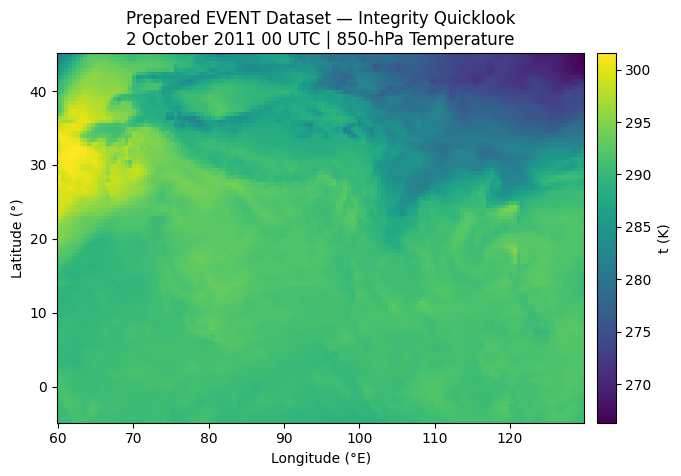

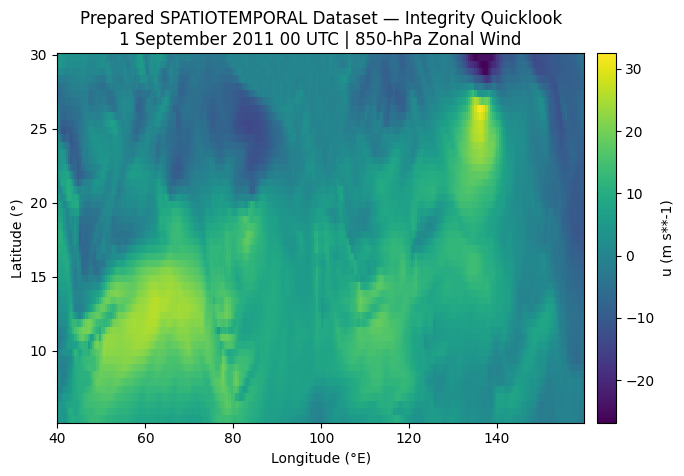

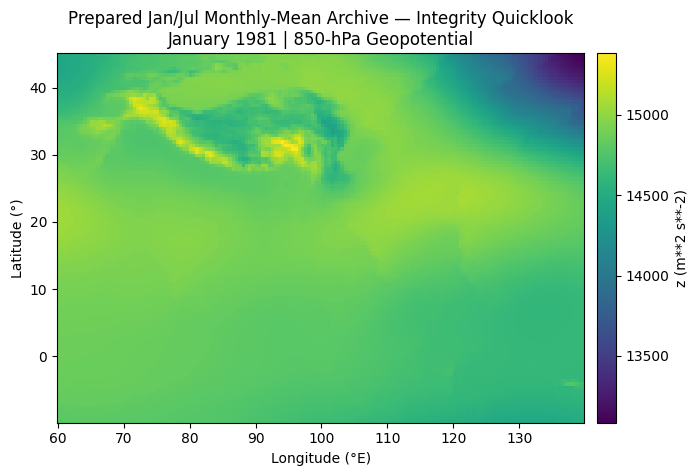

In [38]:
# CELL 38 — Quicklook prepared datasets

# EVENT:
# Use 850-hPa temperature rather than divergence because it is easier
# to interpret visually during data-integrity checking.
quicklook_field(
    PREPARED_DATASETS[
        "EVENT"
    ],
    variable_name="t",
    level_hpa=850.0,
    time_index=0,
    title=(
        "Prepared EVENT Dataset — Integrity Quicklook\n"
        "2 October 2011 00 UTC | 850-hPa Temperature"
    ),
)

# SPATIOTEMPORAL:
# First 6-hourly 850-hPa zonal-wind field.
quicklook_field(
    PREPARED_DATASETS[
        "SPATIOTEMPORAL"
    ],
    variable_name="u",
    time_index=0,
    title=(
        "Prepared SPATIOTEMPORAL Dataset — Integrity Quicklook\n"
        "1 September 2011 00 UTC | 850-hPa Zonal Wind"
    ),
)

# MONTHLY BASELINE:
# This is January 1981 monthly mean — not a climatological mean.
quicklook_field(
    PREPARED_DATASETS[
        "MONTHLY_BASELINE"
    ],
    variable_name="z",
    time_index=0,
    title=(
        "Prepared Jan/Jul Monthly-Mean Archive — Integrity Quicklook\n"
        "January 1981 | 850-hPa Geopotential"
    ),
)

# 34. SHA256 checksum

Checksum เป็น “digital fingerprint” ของไฟล์

หากไฟล์เปลี่ยนแม้เพียงบางส่วน SHA256 จะเปลี่ยน

workflow สำหรับนิสิตภายหลังจะเป็น:

```text
download from GitHub
        ↓
calculate SHA256
        ↓
compare with manifest
        ↓
PASS / FAIL
```

ช่วยตรวจว่าไฟล์ที่นิสิตดาวน์โหลดมาตรงกับ teaching dataset ที่ผู้สอนเตรียมไว้จริง

In [39]:
# CELL 39 — Prepared-data manifest

manifest_rows = []

for dataset_key, path in PREPARED_FILES.items():
    ds = PREPARED_DATASETS[
        dataset_key
    ]

    lat_name = find_coord_name(
        ds,
        "latitude",
    )

    lon_name = find_coord_name(
        ds,
        "longitude",
    )

    time_name = find_coord_name(
        ds,
        "time",
        required=False,
    )

    level_name = find_coord_name(
        ds,
        "level",
        required=False,
    )

    size_mb = file_size_mb(
        path
    )

    if size_mb < GITHUB_WEB_READY_MB:
        github_status = (
            "WEB_UPLOAD_READY"
        )

    elif size_mb < GITHUB_WEB_LIMIT_MB:
        github_status = (
            "WEB_UPLOAD_BORDERLINE"
        )

    elif size_mb < GITHUB_GIT_CAUTION_MB:
        github_status = (
            "GIT_PUSH_ONLY"
        )

    elif size_mb < GITHUB_HARD_LIMIT_MB:
        github_status = (
            "LARGE_GIT_FILE"
        )

    else:
        github_status = (
            "DO_NOT_UPLOAD_AS_NORMAL_GIT_FILE"
        )

    row = {
        "dataset_key": (
            dataset_key
        ),
        "filename": (
            path.name
        ),
        "path": str(
            path
        ),
        "size_MB": (
            size_mb
        ),
        "github_status": (
            github_status
        ),
        "sha256": (
            sha256sum(
                path
            )
        ),
        "variables": ",".join(
            ds.data_vars
        ),
        "dimensions": json.dumps(
            {
                key: int(
                    value
                )
                for key, value in (
                    ds.sizes.items()
                )
            }
        ),
        "longitude_min": float(
            ds[
                lon_name
            ].min()
        ),
        "longitude_max": float(
            ds[
                lon_name
            ].max()
        ),
        "latitude_min": float(
            ds[
                lat_name
            ].min()
        ),
        "latitude_max": float(
            ds[
                lat_name
            ].max()
        ),
        "longitude_step_deg": (
            infer_regular_step(
                ds[
                    lon_name
                ]
            )
        ),
        "latitude_step_deg": (
            infer_regular_step(
                ds[
                    lat_name
                ]
            )
        ),
        "declared_single_pressure_level_hPa": (
            ds.attrs.get(
                "selected_pressure_level_hPa",
                ""
            )
        ),
    }

    if time_name is not None:
        times = pd.DatetimeIndex(
            pd.to_datetime(
                ds[
                    time_name
                ].values
            )
        )

        row[
            "time_start"
        ] = str(
            times.min()
        )

        row[
            "time_end"
        ] = str(
            times.max()
        )

        row[
            "months_present"
        ] = ",".join(
            str(
                month
            )
            for month in sorted(
                times.month.unique()
            )
        )

    else:
        row[
            "time_start"
        ] = ""

        row[
            "time_end"
        ] = ""

        row[
            "months_present"
        ] = ""

    if level_name is not None:
        levels_array = np.atleast_1d(
            np.asarray(
                ds[
                    level_name
                ].values
            )
        )

        row[
            "levels"
        ] = ",".join(
            str(
                value
            )
            for value in (
                levels_array.tolist()
            )
        )

    else:
        row[
            "levels"
        ] = ""

    manifest_rows.append(
        row
    )


PREPARED_MANIFEST = pd.DataFrame(
    manifest_rows
)

display(
    PREPARED_MANIFEST
)

MANIFEST_CSV = (
    METADATA_DIR
    / "era5_teaching_data_manifest.csv"
)

PREPARED_MANIFEST.to_csv(
    MANIFEST_CSV,
    index=False,
)

print(
    "Saved:",
    MANIFEST_CSV,
)

,dataset_key,filename,path,size_MB,github_status,sha256,variables,dimensions,longitude_min,longitude_max,latitude_min,latitude_max,longitude_step_deg,latitude_step_deg,declared_single_pressure_level_hPa,time_start,time_end,months_present,levels
0,EVENT,era5_noul_20111002_05_SEAsia_pressure_levels_0...,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,10.045524,WEB_UPLOAD_READY,ab46627c04643de7067d953479340b0b1fabb6aed06cd6...,"d,z,r,q,t,u,v,vo","{""time"": 4, ""level"": 8, ""latitude"": 100, ""long...",60.125,129.625,-4.625,44.875,0.5,0.5,,2011-10-02 00:00:00,2011-10-05 00:00:00,10,"200,250,300,500,700,850,925,1000"
1,SPATIOTEMPORAL,era5_u850_6hourly_20110901_20111031_Asia_0.5de...,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,8.921192,WEB_UPLOAD_READY,b92be54c89c3af16c3723f8a889b489cb23841d4543aca...,u,"{""time"": 244, ""latitude"": 50, ""longitude"": 240}",40.125,159.625,5.375,29.875,0.5,0.5,850.0,2011-09-01 00:00:00,2011-10-31 18:00:00,"9,10",
2,MONTHLY_BASELINE,era5_850hPa_JanJul_monthlymeans_1981_2020_Asia...,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,22.253628,WEB_UPLOAD_READY,5fa75fbb58eeed45106436f07552b9bca0a2345e69e292...,"z,r,t,u,v,vo","{""time"": 80, ""latitude"": 110, ""longitude"": 160}",60.125,139.625,-9.625,44.875,0.5,0.5,850.0,1981-01-01 00:00:00,2020-07-01 00:00:00,"1,7",


Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/01_metadata/era5_teaching_data_manifest.csv


# 35. การประเมินขนาดสำหรับ GitHub web upload

Course workflow นี้ตั้งใจให้อาจารย์สามารถอัปโหลด prepared NetCDF ผ่านหน้าเว็บของ GitHub ได้โดยตรง

ดังนั้น v2 ใช้เกณฑ์ที่เข้มกว่าการ `git push`:

```text
< 24 MB
→ WEB_UPLOAD_READY

24–25 MB
→ WEB_UPLOAD_BORDERLINE

25–50 MB
→ GIT_PUSH_ONLY

50–100 MB
→ LARGE_GIT_FILE

≥ 100 MB
→ DO_NOT_UPLOAD_AS_NORMAL_GIT_FILE
```

เป้าหมายของชุด teaching data คือให้ **ทั้ง 3 NetCDF ต่ำกว่า 25 MB**

เหตุผลไม่ใช่เพียงข้อจำกัดของ GitHub แต่ยังช่วยให้:

- นิสิตดาวน์โหลดเร็ว
- Colab เริ่มทำงานเร็ว
- repository ไม่หนักเกินไป
- common teaching dataset ใช้งานสะดวก
- ลด technical burden ที่ไม่ใช่วัตถุประสงค์หลักของบทเรียน

หาก output ใดยังเกิน 25 MB ให้ปรับ **teaching representation** อย่างมีเหตุผล เช่น:

1. ลด spatial domain
2. ลด variables ที่ไม่จำเป็น
3. เพิ่ม spatial coarsening
4. แยกไฟล์ตาม teaching purpose

โดยต้องบันทึก preprocessing ใน metadata เสมอ

In [40]:
# CELL 40 — GitHub web-upload readiness table

GITHUB_READINESS = (
    PREPARED_MANIFEST[
        [
            "dataset_key",
            "filename",
            "size_MB",
            "github_status",
        ]
    ]
    .copy()
)

display(
    GITHUB_READINESS
)

web_upload_ready = bool(
    (
        GITHUB_READINESS[
            "size_MB"
        ]
        < GITHUB_WEB_LIMIT_MB
    ).all()
)

if web_upload_ready:
    print(
        "All prepared NetCDF files are below 25 MB."
    )
    print(
        "GitHub browser-upload target: PASS"
    )

else:
    print(
        "At least one prepared NetCDF is >= 25 MB."
    )
    print(
        "GitHub browser-upload target: FAIL"
    )
    print(
        "Reduce the prepared dataset before uploading through the web interface."
    )

,dataset_key,filename,size_MB,github_status
0,EVENT,era5_noul_20111002_05_SEAsia_pressure_levels_0...,10.045524,WEB_UPLOAD_READY
1,SPATIOTEMPORAL,era5_u850_6hourly_20110901_20111031_Asia_0.5de...,8.921192,WEB_UPLOAD_READY
2,MONTHLY_BASELINE,era5_850hPa_JanJul_monthlymeans_1981_2020_Asia...,22.253628,WEB_UPLOAD_READY


All prepared NetCDF files are below 25 MB.
GitHub browser-upload target: PASS


# 36. README_DATASET สำหรับ GitHub

เมื่ออัปไฟล์ prepared data ไป GitHub ควรมี `README_DATASET.md` อธิบายว่า:

- source คืออะไร
- preprocessing ทำอะไร
- มี variables อะไร
- spatial/temporal coverage เท่าใด
- grid spacing เท่าใด
- ไฟล์ไหนใช้กับ Notebook ใด
- มีข้อจำกัดอะไร

นี่ทำให้ repository ไม่กลายเป็นเพียง “โฟลเดอร์ไฟล์ที่ไม่มีคำอธิบาย”

In [41]:
# CELL 41 — Generate README_DATASET.md

manifest_md = PREPARED_MANIFEST[
    [
        "dataset_key",
        "filename",
        "size_MB",
        "variables",
        "time_start",
        "time_end",
        "months_present",
        "levels",
        "declared_single_pressure_level_hPa",
        "longitude_step_deg",
        "latitude_step_deg",
        "github_status",
    ]
].to_markdown(
    index=False
)

README_DATASET_TEXT = f"""# ERA5 Compact Teaching Dataset

## Purpose

ชุดข้อมูลนี้ถูกเตรียมสำหรับรายวิชา **Teaching ERA5 Reanalysis and GIS**
เพื่อใช้ในการเรียนการสอนด้าน atmospheric reanalysis, weather-map analysis,
pressure-level atmosphere, wind-vector analysis, Hovmöller diagrams,
climatological mean-state analysis และ anomaly ด้วย Python/Xarray บน Google Colab

## Scientific interpretation

ERA5 เป็น atmospheric reanalysis ไม่ใช่ direct observation

Prepared files ผ่านกระบวนการ:

- spatial subsetting
- variable selection
- pressure-level selection / explicit single-level metadata
- spatial coarsening สำหรับ student-facing teaching grids
- NetCDF compression
- floating-variable storage as float32
- metadata augmentation
- SHA256 integrity checking

ไม่มีการคำนวณ derived meteorological diagnostics ใน data-preparation stage นี้

## Prepared files

{manifest_md}

## Dataset roles

### EVENT

ใช้สำหรับ Notebook 01–05 และ 09

ข้อมูลประกอบด้วย **four daily 00-UTC synoptic snapshots**
ระหว่าง 2–5 October 2011

ไม่ใช่ daily-mean dataset

Teaching grid ถูก coarsen จาก source 0.25° เป็น 0.5° ด้วย 2×2 arithmetic spatial averaging

ใช้สำหรับ:

- NetCDF/Xarray
- spatial mapping
- pressure-level structure
- temperature / moisture
- wind-vector analysis
- synoptic diagnostics
- Tropical Storm Noul teaching case

### SPATIOTEMPORAL

ใช้สำหรับ Notebook 06

ข้อมูลเป็น 850-hPa zonal wind ที่ temporal spacing จริงประมาณ 6 ชั่วโมง

ใช้สำหรับ:

- time–longitude analysis
- time–latitude analysis
- Hovmöller diagram
- propagation
- persistence

### MONTHLY_BASELINE

ใช้สำหรับ Notebook 07–08

ไฟล์นี้เป็น **January/July monthly-mean archive for individual years**
ไม่ใช่ precomputed climatology

Student Notebook 07 จะสร้าง climatological monthly mean จาก:

monthly means → group by month → multi-year mean

ใช้สำหรับ:

- January climatology
- July climatology
- January–July seasonal contrast
- anomaly สำหรับเดือนที่ source มีจริง

## Important limitation

Months available in the monthly baseline source are:

{CLIM_MONTHS_PRESENT}

ดังนั้น source นี้ **ไม่สามารถให้ October climatology สำหรับ Noul 2011**

ห้ามใช้ January หรือ July climatology แทน October climatology

## 850-hPa high-terrain caution

SPATIOTEMPORAL และ MONTHLY_BASELINE เป็น single-level 850-hPa archives

850-hPa fields over high terrain ต้องตีความอย่างระมัดระวัง เพราะ 850-hPa pressure surface
อาจอยู่ต่ำกว่าพื้นผิวท้องถิ่น โดยเฉพาะบริเวณ Tibetan Plateau และเทือกเขาสูง

## Integrity

ตรวจ SHA256 จาก:

`era5_teaching_data_manifest.csv`

## Teaching principle

Prepared grid spacing is a teaching representation.

It must not be interpreted as the effective physical resolution of ERA5.
"""

README_DATASET_PATH = (
    REPORT_DIR
    / "README_DATASET.md"
)

README_DATASET_PATH.write_text(
    README_DATASET_TEXT,
    encoding="utf-8",
)

print(
    "Saved:",
    README_DATASET_PATH,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_reports/README_DATASET.md


# 37. สิ่งที่นิสิตควรเรียนรู้จาก data preparation

แม้ Notebook 00A เป็น Instructor notebook แต่แนวคิดในบทนี้สำคัญต่อ environmental data science:

### 1. ข้อมูลใหญ่ไม่ได้แปลว่าต้องใช้ทั้งหมด

คำถามวิจัยหรือคำถามการเรียนเป็นตัวกำหนดว่า:

```text
ใช้พื้นที่ไหน
ใช้เวลาไหน
ใช้ระดับไหน
ใช้ตัวแปรไหน
```

### 2. การลดขนาดข้อมูลต้องมีเหตุผล

```text
subset
→ ไม่เปลี่ยน grid spacing

coarsen
→ เปลี่ยน spatial representation

compression
→ ลด storage โดยไม่เปลี่ยน physical units

float32
→ ลด numerical precision เล็กน้อย
```

### 3. Metadata เป็นส่วนหนึ่งของข้อมูล

ไฟล์ที่ไม่มี metadata ทำให้ผู้ใช้ไม่รู้ว่า:

- หน่วยอะไร
- ระดับอะไร
- source อะไร
- ผ่าน preprocessing อะไร

### 4. Reproducibility ต้องตรวจได้

```text
source
→ code
→ prepared output
→ checksum
→ manifest
```

# 38. ข้อควรระวังทางวิทยาศาสตร์

1. ERA5 เป็น reanalysis ไม่ใช่ direct observation
2. spatial grid spacing ไม่เท่ากับ effective atmospheric resolution
3. coarsening ไม่ได้สร้างข้อมูลใหม่ที่ละเอียดขึ้น
4. spatial averaging อาจลด local extrema
5. `float32` มี precision ต่ำกว่า `float64`
6. pressure-level data ไม่ใช่ model-level data
7. 850 hPa ไม่ได้อยู่เหนือพื้นทุกแห่งเสมอ โดยเฉพาะพื้นที่ภูเขาสูง
8. longitude/latitude ต้องตรวจ convention และ ordering
9. monthly mean file ต้องตรวจ months จริงจาก coordinate
10. January/July climatology ไม่สามารถใช้แทน October climatology
11. Noul event analysis กับ climatological anomaly ต้องใช้ baseline ของเดือนเดียวกันจึงจะเหมาะสม
12. prepared teaching dataset ไม่ควรถูกนำไปอ้างว่าเป็น original ERA5 archive

# 39. แนวทางต่อยอดสำหรับ Notebook 01–09

หลังอัปโหลด prepared data ไป GitHub แล้ว student workflow ควรเป็น:

```text
00 — Download & Data Audit
 ↓
01 — NetCDF & Xarray Fundamentals
 ↓
02 — Spatial Subsetting & Cartopy
 ↓
03 — Pressure-Level Atmospheric Structure
 ↓
04 — Wind & Vector Analysis
 ↓
05 — Synoptic Weather Maps & Dynamics
 ↓
06 — Hovmöller & Spatiotemporal Analysis
 ↓
07 — Climatology
 ↓
08 — Anomaly
 ↓
09 — Integrated Case Study
```

ทุก Notebook ควรใช้หลักเดียวกัน:

```text
Theory
→ Data
→ Code
→ Figure
→ Interpretation
→ Limitation
→ Exercise
```

# 40. สมการใน Student Notebooks

สำหรับ Google Colab ให้ใช้ MathJax format:

inline:

```markdown
$V=\sqrt{u^2+v^2}$
```

display:

```markdown
$$
\zeta
=
\frac{\partial v}{\partial x}
-
\frac{\partial u}{\partial y}
$$
```

หลีกเลี่ยง MathJax delimiter แบบ backslash-parentheses และ backslash-brackets

เพื่อให้ rendering สม่ำเสมอกับ course notebooks อื่น

In [42]:
# CELL 42 — Preparation metadata

PREPARATION_METADATA = pd.DataFrame(
    [
        (
            "course_name",
            "Teaching ERA5 Reanalysis and GIS",
        ),
        (
            "dataset_preparation_version",
            "v2_GitHubWeb",
        ),
        (
            "notebook",
            "00A_Prepare_ERA5_Teaching_Datasets_v2_GitHubWeb.ipynb",
        ),
        (
            "notebook_role",
            "Instructor dataset-engineering notebook",
        ),
        (
            "source_directory",
            str(
                SOURCE_DIR
            ),
        ),
        (
            "event_domain",
            str(
                EVENT_DOMAIN
            ),
        ),
        (
            "spatiotemporal_domain",
            str(
                SPATIOTEMPORAL_DOMAIN
            ),
        ),
        (
            "monthly_baseline_domain",
            str(
                CLIMATOLOGY_DOMAIN
            ),
        ),
        (
            "event_source_resolution_deg",
            EVENT_SOURCE_RESOLUTION_DEG,
        ),
        (
            "event_teaching_resolution_deg",
            EVENT_TARGET_RESOLUTION_DEG,
        ),
        (
            "spatiotemporal_teaching_resolution_deg",
            TARGET_COARSE_RESOLUTION_DEG,
        ),
        (
            "monthly_baseline_teaching_resolution_deg",
            TARGET_COARSE_RESOLUTION_DEG,
        ),
        (
            "spatiotemporal_time_step_hours",
            SPATIAL_TIME_STEP_HOURS,
        ),
        (
            "spatiotemporal_selected_level_hPa",
            SPATIAL_SELECTED_LEVEL_HPA,
        ),
        (
            "monthly_baseline_selected_level_hPa",
            CLIM_SELECTED_LEVEL_HPA,
        ),
        (
            "monthly_baseline_months_present",
            str(
                CLIM_MONTHS_PRESENT
            ),
        ),
        (
            "monthly_baseline_semantics",
            "Per-year January/July monthly means; not precomputed climatology.",
        ),
        (
            "event_temporal_semantics",
            "Four daily 00-UTC synoptic snapshots; not daily means.",
        ),
        (
            "float_storage_dtype",
            FLOAT_STORAGE_DTYPE,
        ),
        (
            "netcdf_compression_level",
            NETCDF_COMPRESSION_LEVEL,
        ),
        (
            "github_web_ready_target_MB",
            GITHUB_WEB_READY_MB,
        ),
        (
            "github_web_upload_limit_MB",
            GITHUB_WEB_LIMIT_MB,
        ),
        (
            "github_git_caution_MB",
            GITHUB_GIT_CAUTION_MB,
        ),
        (
            "github_hard_limit_MB",
            GITHUB_HARD_LIMIT_MB,
        ),
        (
            "created_UTC",
            pd.Timestamp.utcnow().isoformat(),
        ),
    ],
    columns=[
        "parameter",
        "value",
    ],
)

display(
    PREPARATION_METADATA
)

PREPARATION_METADATA_CSV = (
    METADATA_DIR
    / "00A_preparation_metadata.csv"
)

PREPARATION_METADATA.to_csv(
    PREPARATION_METADATA_CSV,
    index=False,
)

,parameter,value
0,course_name,Teaching ERA5 Reanalysis and GIS
1,dataset_preparation_version,v2_GitHubWeb
2,notebook,00A_Prepare_ERA5_Teaching_Datasets_v2_GitHubWe...
3,notebook_role,Instructor dataset-engineering notebook
4,source_directory,/content/drive/MyDrive/1shared_etc/1ข้อมูลยูทู...
5,event_domain,"{'lon_min': 60.0, 'lon_max': 130.0, 'lat_min':..."
6,spatiotemporal_domain,"{'lon_min': 40.0, 'lon_max': 160.0, 'lat_min':..."
7,monthly_baseline_domain,"{'lon_min': 60.0, 'lon_max': 140.0, 'lat_min':..."
8,event_source_resolution_deg,0.25
9,event_teaching_resolution_deg,0.5


# 41. Final output inventory

In [43]:
# CELL 43 — Output inventory

EXPECTED_OUTPUTS = [
    EVENT_OUTPUT,
    SPATIOTEMPORAL_OUTPUT,
    CLIMATOLOGY_OUTPUT,
    SOURCE_AUDIT_CSV,
    VARIABLE_INVENTORY_CSV,
    VALIDATION_CSV,
    MANIFEST_CSV,
    README_DATASET_PATH,
    PREPARATION_METADATA_CSV,
]

OUTPUT_INVENTORY = pd.DataFrame(
    {
        "path": [
            str(
                path
            )
            for path in (
                EXPECTED_OUTPUTS
            )
        ],
        "exists": [
            Path(
                path
            ).exists()
            for path in (
                EXPECTED_OUTPUTS
            )
        ],
        "size_MB": [
            (
                file_size_mb(
                    path
                )
                if Path(
                    path
                ).exists()
                and Path(
                    path
                ).is_file()
                else np.nan
            )
            for path in (
                EXPECTED_OUTPUTS
            )
        ],
    }
)

display(
    OUTPUT_INVENTORY
)

,path,exists,size_MB
0,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,10.045524
1,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,8.921192
2,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,22.253628
3,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,0.001419
4,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,0.001439
5,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,0.001115
6,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,0.001554
7,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,0.004835
8,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,True,0.001236


# 42. Final readiness

Notebook 00A ผ่านเมื่อ:

```text
3 source files found
        ↓
source audit complete
        ↓
3 prepared NetCDF files created
        ↓
all prepared files reopen successfully
        ↓
validation PASS
        ↓
SHA256 generated
        ↓
manifest generated
        ↓
README_DATASET generated
```

หาก prepared NetCDF ใดใหญ่เกิน 100 MB ให้ถือว่า **ยังไม่พร้อมสำหรับ normal GitHub upload**

In [44]:
# CELL 44 — Final readiness check

readiness_rows = []


def add_readiness(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": (
                item
            ),
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": (
                note
            ),
        }
    )


add_readiness(
    "All source files found",
    all(
        path.exists()
        for path in (
            SOURCE_FILES.values()
        )
    ),
)

add_readiness(
    "Source audit exported",
    SOURCE_AUDIT_CSV.exists(),
)

add_readiness(
    "Variable inventory exported",
    VARIABLE_INVENTORY_CSV.exists(),
)

add_readiness(
    "EVENT NetCDF created",
    EVENT_OUTPUT.exists(),
    (
        f"{file_size_mb(EVENT_OUTPUT):.2f} MB"
        if EVENT_OUTPUT.exists()
        else ""
    ),
)

add_readiness(
    "SPATIOTEMPORAL NetCDF created",
    SPATIOTEMPORAL_OUTPUT.exists(),
    (
        f"{file_size_mb(SPATIOTEMPORAL_OUTPUT):.2f} MB"
        if SPATIOTEMPORAL_OUTPUT.exists()
        else ""
    ),
)

add_readiness(
    "CLIMATOLOGY NetCDF created",
    CLIMATOLOGY_OUTPUT.exists(),
    (
        f"{file_size_mb(CLIMATOLOGY_OUTPUT):.2f} MB"
        if CLIMATOLOGY_OUTPUT.exists()
        else ""
    ),
)

add_readiness(
    "Prepared-data validation",
    bool(
        (
            VALIDATION_TABLE[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_readiness(
    "Manifest exported",
    MANIFEST_CSV.exists(),
)

add_readiness(
    "README_DATASET generated",
    README_DATASET_PATH.exists(),
)

add_readiness(
    "All prepared NetCDF files below 25 MB for GitHub web upload",
    bool(
        (
            PREPARED_MANIFEST[
                "size_MB"
            ]
            < GITHUB_WEB_LIMIT_MB
        ).all()
    ),
    (
        ", ".join(
            f"{row.dataset_key}={row.size_MB:.1f}MB"
            for row in (
                PREPARED_MANIFEST.itertuples()
            )
        )
    ),
)


READINESS_00A = pd.DataFrame(
    readiness_rows
)

display(
    READINESS_00A
)

NOTEBOOK_00A_READY = bool(
    (
        READINESS_00A[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_00A_CSV = (
    METADATA_DIR
    / "00A_readiness_check.csv"
)

READINESS_00A.to_csv(
    READINESS_00A_CSV,
    index=False,
)

print()

if NOTEBOOK_00A_READY:
    print(
        "NOTEBOOK 00A — ERA5 TEACHING DATA PREPARATION READY"
    )

    print(
        "Next: upload the three <25-MB prepared NetCDF files + manifest + README_DATASET to GitHub."
    )

    print(
        "Then build Student Notebook 00 — Download and Data Audit."
    )

else:
    print(
        "NOTEBOOK 00A REQUIRES REVIEW"
    )

,item,status,note
0,All source files found,PASS,
1,Source audit exported,PASS,
2,Variable inventory exported,PASS,
3,EVENT NetCDF created,PASS,10.05 MB
4,SPATIOTEMPORAL NetCDF created,PASS,8.92 MB
5,CLIMATOLOGY NetCDF created,PASS,22.25 MB
6,Prepared-data validation,PASS,
7,Manifest exported,PASS,
8,README_DATASET generated,PASS,
9,All prepared NetCDF files below 25 MB for GitH...,PASS,"EVENT=10.0MB, SPATIOTEMPORAL=8.9MB, MONTHLY_BA..."



NOTEBOOK 00A — ERA5 TEACHING DATA PREPARATION READY
Next: upload the three <25-MB prepared NetCDF files + manifest + README_DATASET to GitHub.
Then build Student Notebook 00 — Download and Data Audit.


# 43. หลังจากรันผ่านแล้ว ต้องอัปโหลดอะไรขึ้น GitHub?

เป้าหมายของ v2 คือให้ prepared NetCDF **ทุกไฟล์ต่ำกว่า 25 MB**
เพื่อให้อัปผ่าน GitHub web interface ได้โดยตรง

แนะนำให้ upload:

```text
data/
├── era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc
├── era5_u850_6hourly_..._Asia_0.5deg.nc
└── era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc

metadata/
├── era5_teaching_data_manifest.csv
└── 00A_preparation_metadata.csv

README_DATASET.md
```

ชื่อไฟล์ SPATIOTEMPORAL จะสะท้อน time range ที่ตรวจจาก source จริง

จากนั้น Student Notebook 00 จะทำ:

```text
GitHub
  ↓
download prepared files
  ↓
Google Drive
  ↓
verify SHA256
  ↓
audit dimensions / coordinates / variables
  ↓
COURSE DATA READY
```

> หาก final readiness ยังมีไฟล์ใด `>= 25 MB` ให้ยังไม่อัปโหลด และกลับมาปรับ domain / variable set / coarsening ก่อน

# 44. Exercise สำหรับนิสิตระดับปริญญาโทหรือผู้ช่วยสอน

### Exercise 1 — Domain sensitivity

เปรียบเทียบขนาดไฟล์ EVENT เมื่อใช้:

```text
60–130°E, 5°S–45°N
```

กับ:

```text
75–125°E, 0–35°N
```

อภิปรายว่า spatial context ที่สูญเสียไปคุ้มกับการลดขนาดหรือไม่

### Exercise 2 — Resolution sensitivity

เปรียบเทียบ Hovmöller dataset:

```text
0.25°
vs
0.5°
vs
1.0°
```

ดูผลต่อ:

- file size
- field extrema
- spatial pattern

### Exercise 3 — Precision

เลือกตัวแปรหนึ่ง แล้วเปรียบเทียบค่าระหว่าง source `float64` กับ prepared `float32`

คำนวณ:

$$
\Delta X
=
X_{32}
-
X_{64}
$$

อภิปรายว่าความแตกต่างมีนัยสำคัญต่อ teaching analysis หรือไม่

### Exercise 4 — Climatology availability

ตรวจ months ใน source climatology แล้วตอบว่า:

> สามารถคำนวณ October anomaly ของ Noul 2011 จาก source นี้ได้หรือไม่? เพราะเหตุใด?

# ข้อความสำคัญที่ต้องจำ

1. ERA5 เป็น reanalysis ไม่ใช่ direct observation
2. ตรวจ metadata ก่อนประมวลผลเสมอ
3. `time × level × latitude × longitude` คือแกนหลักของ atmospheric data cube
4. subsetting ≠ coarsening
5. coarsening ≠ regridding
6. grid spacing ≠ effective physical resolution
7. pressure-level availability ต้องตรวจจาก source
8. variable availability ต้องตรวจจาก source
9. month availability ต้องตรวจจาก source
10. spatial averaging อาจลด extrema
11. `float32` ลด storage แต่ลด precision ด้วย
12. compression ต่างจาก spatial coarsening
13. prepared teaching data ต้องมี provenance
14. checksum ช่วยตรวจ file integrity
15. prepared file ต้อง reopen และ validate
16. filename ไม่ใช่หลักฐานของ file content
17. January/July data ไม่สามารถแทน October climatology
18. data preparation ต้องแยกจาก scientific derivation
19. compact teaching dataset ควรตอบ learning objectives โดยไม่สร้าง technical burden เกินจำเป็น
20. reproducible course เริ่มจาก reproducible data architecture

In [45]:
# CELL 45 — Close open datasets

for dataset in (
    SOURCE_DATASETS.values()
):
    try:
        dataset.close()
    except Exception:
        pass

for dataset in (
    PREPARED_DATASETS.values()
):
    try:
        dataset.close()
    except Exception:
        pass

print(
    "Source and prepared NetCDF file handles closed."
)

Source and prepared NetCDF file handles closed.
